<a href="https://colab.research.google.com/github/Shashwat-19/Spam-Email-Detection/blob/main/Spam_Email_Detection_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Email Detection Pipeline
---
<center> <h2>Architecture Overview</h2>

```
Raw Email / SMS (str)
       │
       ▼
┌──────────────────────────────────┐
│  1. Text Preprocessing           │
│  • URL normalization             │
  │  • Number normalization          │  
│  • Special char removal          │
└──────────────────────────────────┘
       │
       ▼
┌──────────────────────────────────┐
│  2. Feature Engineering          │
│  • TF-IDF Vectorization          │
│  • Handcrafted Features          │
│  • Feature Combination           │
└──────────────────────────────────┘
       │
       ▼
┌──────────────────────────────────┐
│  3. Model Training               │
│  • Naive Bayes                   │
│  • Logistic Regression           │
│  • Linear SVM                    │
└──────────────────────────────────┘
       │
       ▼
┌──────────────────────────────────┐
│  4. Level-1 Fine-Tuning          │
│  • Hyperparameter Optimization   │
│  • Cross-Validation              │
└──────────────────────────────────┘
       │
       ▼
┌──────────────────────────────────┐
│  5. Level-2 Fine-Tuning          │
│  • Threshold Optimization        │
│  • Ensemble Calibration          │
└──────────────────────────────────┘
       │
       ▼
┌──────────────────────────────────┐
│  6. Model Evaluation & Saving    │
│  • Confusion Matrix              │
│  • ROC-AUC Analysis              │
│  • Artifact Persistence          │
└──────────────────────────────────┘
       │
       ▼
   Production Inference
```

---
**Author**: Spam Detection Pipeline v2.0  
**Purpose**: Production-ready ML pipeline with 2-level fine-tuning


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#  CELL 1 — SETUP & CONFIGURATION
# ═════════════════════════════════════════════════════════════════
# Purpose: Initialize all dependencies, configure logging, and define the central configuration dataclass that drives the entire pipeline.
# Key Components:
# • All imports g here (no scattered imports in other cells)
# • PipelineConfig dataclass: single source of truth for hyperparameters
# • Logging setup: structured output for debugging and monitoring
# • Random seed initialization: reproducibility across all operations
# ═══════════════════════════════════════════════════════════════════════

# ═════════════════════════════════════════════════════════════
# STANDARD LIBRARY IMPORTS
# ═════════════════════════════════════════════════════════════
import os
import re
import sys
import time
import logging
import warnings
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple, Any

# ════════════════════════════════════════
# DATA SCIENCE IMPORTS
# ════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ═════════════════════════════
# SCIKIT-LEARN IMPORTS
# ═════════════════════════════
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import MaxAbsScaler
from scipy.sparse import hstack, csr_matrix
from scipy.stats import uniform, loguniform

# ════════════════════════════════════════
# CONFIGURATION & ENVIRONMENT SETUP
# ══════════════════════════════════════════

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore")

# Configure pandas display settings for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# ══════════════════════════════════
# LOGGING CONFIGURATION
# ════════════════════════════════════════════════════
# Production-grade logging with timestamp, level, and message format
# This enables easy debugging and monitoring in production environments

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("SpamPipeline")

# ════════════════════════════════════════════
# PIPELINE CONFIGURATION DATACLASS
# ══════════════════════════════════════════════
# Using a dataclass provides:
#   1. Type safety and IDE autocomplete
#   2. Easy serialization for experiment tracking
#   3. Single source of truth for all hyperparameters
#   4. No magic numbers scattered throughout the code

@dataclass
class PipelineConfig:
    """
    Central configuration for the entire spam detection pipeline.
    Modify values here to experiment with different settings.
    """
    # ────────────────────────────────────────────────
    # DATA PATHS
    # ──────────────────────────────────────────────────
    # Update this path to point to your dataset location
    data_path: str = "/content/drive/MyDrive/spam.csv"
    model_dir: str = "models"

    # ────────────────────────────────────────────────────────
    # REPRODUCIBILITY
    # ───────────────────────────────────────────
    # Single seed controls all random operations for full reproducibility
    random_seed: int = 42

    # ─────────────────────────
    # DATA SCHEMA
    # ─────────────────────────
    text_col: str = "text"
    label_col: str = "label"
    test_size: float = 0.20
    val_size: float = 0.15  # Validation split from training data

    # ───────────────────────────────────────
    # TF-IDF HYPERPARAMETERS
    # ─────────────────────────────────────────
    # max_features: Vocabulary cap (prevents memory explosion on large corpora)
    # ngram_range: (1,2) captures unigrams + bigrams ("free", "free money")
    # min_df: Minimum document frequency (filters rare noise)
    # sublinear_tf: log(1+tf) dampens impact of very frequent terms
    tfidf_max_features: int = 15_000
    tfidf_ngram_range: tuple = (1, 2)
    tfidf_min_df: int = 2
    tfidf_sublinear_tf: bool = True

    # ──────────────────────────────────────────────
    # FINE-TUNING CONFIGURATION
    # ────────────────────────────────────────────────
    # Level 1: Hyperparameter search
    level1_cv_folds: int = 5
    level1_n_iter: int = 20  # RandomizedSearchCV iterations

    # Level 2: Threshold and ensemble tuning
    level2_threshold_steps: int = 100  # Granularity for threshold search
    level2_ensemble_weights_search: bool = True

    # ─────────────────────────────────
    # MODEL VERSIONING
    # ─────────────────────────────────────
    model_version: str = datetime.now().strftime("%Y%m%d_%H%M%S")

    # ─────────────────────────────────────────────
    # INFERENCE DEFAULTS
    # ────────────────────────────────────────────────
    classification_threshold: float = 0.5


# ═════════════════════════════════════════════════════
# INITIALIZE CONFIGURATION
# ══════════════════════════════════════════════════════════
CFG = PipelineConfig()

# Create model directory if it doesn't exist
Path(CFG.model_dir).mkdir(parents=True, exist_ok=True)

# Set global random seed for reproducibility
np.random.seed(CFG.random_seed)

# ═════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 1 COMPLETE: Setup & Configuration")
logger.info("=" * 70)
logger.info("Python version: %s", sys.version.split()[0])
logger.info("NumPy version: %s", np.__version__)
logger.info("Pandas version: %s", pd.__version__)
logger.info("Scikit-learn version: %s", __import__("sklearn").__version__)
logger.info("Model version: %s", CFG.model_version)
logger.info("Model artifacts directory: %s/", CFG.model_dir)
logger.info("Random seed: %d", CFG.random_seed)
print("\n" + "CELL 1 COMPLETE: All dependencies loaded and configuration initialized.\n")



CELL 1 COMPLETE: All dependencies loaded and configuration initialized.



In [5]:
# ═════════════════════════
# CELL 2 — DATA LOADING & VALIDATION
# ═════════════════════════════════════
# Purpose: Load the spam dataset with robust error handling and validation.
# Key Features:
# • Multi-encoding fallback (UTF-8 → Latin-1 → CP1252)
# • Flexible column mapping for different dataset formats
# • Schema validation with explicit error messages
# • Data quality checks (null removal, deduplication)
# • Label encoding with validation (no silent failures)
# ═══════════════════════════════════════════

def load_dataset(path: str, text_col: str, label_col: str) -> pd.DataFrame:
    """
    Load and validate the spam dataset with production-grade error handling.

    Supports multiple CSV formats including the Kaggle SMS Spam Collection:
    https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

    Parameters:
    -----------
    path : str
        Path to the CSV file
    text_col : str
        Expected name for the text column
    label_col : str
        Expected name for the label column

    Returns:
    --------
    pd.DataFrame
        Cleaned dataset with 'text' and 'label' columns

    Raises:
    -------
    RuntimeError: If file cannot be loaded with any encoding
    ValueError: If required columns are missing or labels are invalid
    """
    # ──────────────────────────────────────
    # STEP 1: Try multiple encodings (Kaggle SMS dataset uses Latin-1)
    # ────────────────────────────────────────────────
    encodings = ["utf-8", "latin-1", "cp1252"]
    df = None

    for encoding in encodings:
        try:
            df = pd.read_csv(path, encoding=encoding)
            logger.info("Successfully loaded dataset with encoding: %s", encoding)
            break
        except (UnicodeDecodeError, FileNotFoundError) as e:
            logger.warning("Failed to load with encoding %s: %s", encoding, str(e))

    if df is None:
        raise RuntimeError(f"Could not load dataset from: {path}. Check file exists and encoding.")

    # ─────────────────────────────────────
    # STEP 2: Normalize column names
    # ──────────────────────────────────────────
    # Strip whitespace and convert to lowercase for consistent matching
    df.columns = df.columns.str.strip().str.lower()

    # Remove unnamed columns (artifacts from extra commas in CSV)
    df = df.loc[:, ~df.columns.str.startswith("unnamed")]

    # ─────────────────────────────────────────────────
    # STEP 3: Flexible column mapping
    # ─────────────────────────────────────────────────────────────
    # Handle both Kaggle format (v1/v2) and standard format (label/text)
    column_mapping = {}
    for col in df.columns:
        if col in ("v1", label_col, "label", "class", "category"):
            column_mapping[col] = label_col
        elif col in ("v2", text_col, "text", "message", "sms", "email"):
            column_mapping[col] = text_col

    df = df.rename(columns=column_mapping)

    # ───────────────────────────────────────────────────
    # STEP 4: Schema validation
    # ──────────────────────────────────────────────
    required_columns = {label_col, text_col}
    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(
            f"Dataset missing required columns: {missing_columns}. "
            f"Found columns: {list(df.columns)}"
        )

    # Keep only required columns
    df = df[[text_col, label_col]].copy()

    # ────────────────────────────────────────────────────────
    # STEP 5: Label encoding with validation
    # ────────────────────────────────────────────────────────
    # Explicit mapping ensures deterministic label assignment
    label_mapping = {"ham": 0, "spam": 1}
    df[label_col] = df[label_col].str.strip().str.lower().map(label_mapping)

    # Check for unmapped labels (data quality gate)
    if df[label_col].isna().any():
        unmapped_labels = df[df[label_col].isna()][label_col].unique()
        raise ValueError(f"Unexpected label values found: {unmapped_labels}")

    df[label_col] = df[label_col].astype(int)

    # ───────────────────────────────────────────────
    # STEP 6: Data cleaning
    # ──────────────────────────────────────────────────────
    n_before = len(df)

    # Remove null values
    df = df.dropna()

    # Remove exact duplicates based on text content
    df = df.drop_duplicates(subset=[text_col])

    n_after = len(df)
    n_removed = n_before - n_after

    if n_removed > 0:
        logger.info("Removed %d rows (nulls/duplicates)", n_removed)

    # Reset index for clean iteration
    df = df.reset_index(drop=True)

    # ─────────────────────────────────────────────────
    # STEP 7: Summary statistics
    # ─────────────────────────────────────────────
    spam_rate = df[label_col].mean() * 100
    ham_rate = 100 - spam_rate

    logger.info("Dataset loaded successfully:")
    logger.info("  Total samples: %d", len(df))
    logger.info("  Ham samples: %d (%.2f%%)", (df[label_col] == 0).sum(), ham_rate)
    logger.info("  Spam samples: %d (%.2f%%)", (df[label_col] == 1).sum(), spam_rate)

    return df


# ══════════════════════════════════════════════
# LOAD THE DATASET
# ══════════════════════════════════════════════
df = load_dataset(CFG.data_path, CFG.text_col, CFG.label_col)

# Display sample data
print("\n── Sample Data Preview ──")
print(df.head(10).to_string())

# ═════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 2 COMPLETE: Data Loading & Validation")
logger.info("=" * 70)
print("\n" + "CELL 2 COMPLETE: Dataset loaded and validated successfully.\n")



── Sample Data Preview ──
                                                                                                                                                               text  label
0                                                   Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...      0
1                                                                                                                                     Ok lar... Joking wif u oni...      0
2       Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's      1
3                                                                                                                 U dun say so early hor... U c already then say...      0
4                                                                                                     Nah I don't thin

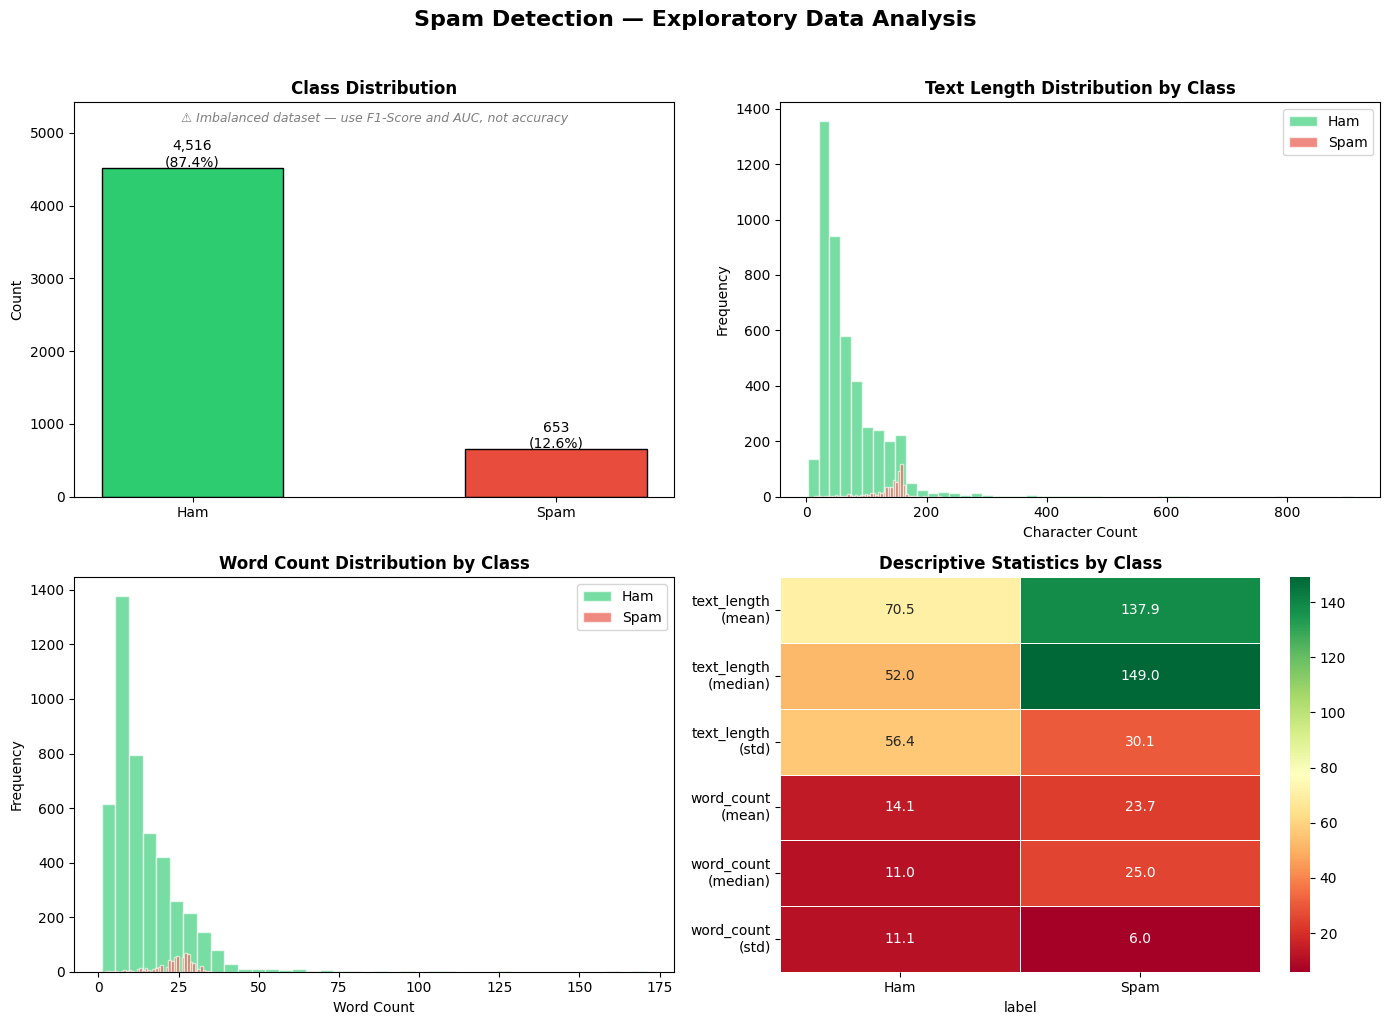


══════════════════════════════════════════════════════════════════════
  EXPLORATORY DATA ANALYSIS SUMMARY
══════════════════════════════════════════════════════════════════════

── Class Distribution ──
  Ham: 4,516 samples (87.37%)
  Spam: 653 samples (12.63%)

── Text Length Statistics ──
        count   mean   std   min    25%    50%    75%    max
label                                                       
0      4516.0   70.5  56.4   2.0   34.0   52.0   90.0  910.0
1       653.0  137.9  30.1  13.0  132.0  149.0  157.0  224.0

── Word Count Statistics ──
        count  mean   std  min   25%   50%   75%    max
label                                                  
0      4516.0  14.1  11.1  1.0   7.0  11.0  18.0  171.0
1       653.0  23.7   6.0  2.0  22.0  25.0  28.0   35.0

✅ CELL 3 COMPLETE: EDA visualizations saved to eda_overview.png



In [6]:
# ═══════════════════════════════
# CELL 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ═══════════════════════════════════════════════════════════════════
# Purpose: Understand the data distribution and characteristics to inform  feature engineering and model selection decisions.
# Key Insights We Seek:
# 1. Class imbalance ratio → affects metric choice (F1 over accuracy)
# 2. Text length patterns → spam often longer (promotional content)
# 3. Word count distributions → vocabulary complexity differences
# 4. Statistical summary → guides preprocessing decisions
# ══════════════════════════════

def run_eda(df: pd.DataFrame, text_col: str, label_col: str) -> Dict[str, Any]:
    """
    Comprehensive exploratory data analysis for spam detection.

    Parameters:
    -----------
    df : pd.DataFrame
        The dataset with text and label columns
    text_col : str
        Name of the text column
    label_col : str
        Name of the label column

    Returns:
    --------
    Dict containing computed statistics for downstream use
    """
    # ──────────────────────────────────────
    # COMPUTE DERIVED FEATURES FOR ANALYSIS
    # ────────────────────────────────────────────────
    df_analysis = df.copy()
    df_analysis["text_length"] = df_analysis[text_col].str.len()
    df_analysis["word_count"] = df_analysis[text_col].str.split().str.len()

    # Label name mapping for display
    label_names = {0: "Ham", 1: "Spam"}

    # ────────────────────────────────────────────────────
    # CREATE VISUALIZATION GRID
    # ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Spam Detection — Exploratory Data Analysis",
                 fontsize=16, fontweight="bold", y=1.02)

    # Color scheme: Green for Ham (good), Red for Spam (danger)
    colors = {"Ham": "#2ecc71", "Spam": "#e74c3c"}

    # ─────────────────────────────────────────────
    # PLOT 1: Class Distribution (Bar Chart)
    # ──────────────────────────────────────────────
    ax = axes[0, 0]
    counts = df_analysis[label_col].map(label_names).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[colors[c] for c in counts.index],
                  edgecolor="black", width=0.5)

    # Add count and percentage labels on bars
    for bar, val in zip(bars, counts.values):
        percentage = val / len(df_analysis) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f"{val:,}\n({percentage:.1f}%)", ha="center", fontsize=10)

    ax.set_title("Class Distribution", fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_ylim(0, counts.max() * 1.2)

    # Add imbalance warning annotation
    ax.text(0.5, 0.95, "⚠ Imbalanced dataset — use F1-Score and AUC, not accuracy",
            ha="center", transform=ax.transAxes, fontsize=9, color="gray",
            style="italic")

    # ────────────────────────────────────────────────────
    # PLOT 2: Text Length Distribution by Class
    # ───────────────────────────────────────────────
    ax = axes[0, 1]
    for label, color in [(0, colors["Ham"]), (1, colors["Spam"])]:
        subset = df_analysis[df_analysis[label_col] == label]["text_length"]
        ax.hist(subset, bins=50, alpha=0.65, label=label_names[label],
                color=color, edgecolor="white")

    ax.set_title("Text Length Distribution by Class", fontweight="bold")
    ax.set_xlabel("Character Count")
    ax.set_ylabel("Frequency")
    ax.legend()

    # ──────────────────────────────────────────────
    # PLOT 3: Word Count Distribution by Class
    # ──────────────────────────────────────────────────────────
    ax = axes[1, 0]
    for label, color in [(0, colors["Ham"]), (1, colors["Spam"])]:
        subset = df_analysis[df_analysis[label_col] == label]["word_count"]
        ax.hist(subset, bins=40, alpha=0.65, label=label_names[label],
                color=color, edgecolor="white")

    ax.set_title("Word Count Distribution by Class", fontweight="bold")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend()

    # ──────────────────────────────────────────────────
    # PLOT 4: Descriptive Statistics Heatmap
    # ───────────────────────────────────────────
    ax = axes[1, 1]
    stats = df_analysis.groupby(df_analysis[label_col].map(label_names))[
        ["text_length", "word_count"]
    ].agg(["mean", "median", "std"])

    # Flatten multi-level column names
    stats.columns = [f"{col[0]}\n({col[1]})" for col in stats.columns]

    sns.heatmap(stats.T, annot=True, fmt=".1f", cmap="RdYlGn",
                ax=ax, linewidths=0.5)
    ax.set_title("Descriptive Statistics by Class", fontweight="bold")

    plt.tight_layout()
    plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ──────────────────────────────────────────────────────────
    # CONSOLE SUMMARY OUTPUT
    # ───────────────────────────────────
    print("\n" + "═" * 70)
    print("  EXPLORATORY DATA ANALYSIS SUMMARY")
    print("═" * 70)

    print("\n── Class Distribution ──")
    for label, name in label_names.items():
        count = (df_analysis[label_col] == label).sum()
        pct = count / len(df_analysis) * 100
        print(f"  {name}: {count:,} samples ({pct:.2f}%)")

    print("\n── Text Length Statistics ──")
    print(df_analysis.groupby(label_col)["text_length"].describe().round(1).to_string())

    print("\n── Word Count Statistics ──")
    print(df_analysis.groupby(label_col)["word_count"].describe().round(1).to_string())

    # Return statistics for downstream use
    eda_stats = {
        "total_samples": len(df_analysis),
        "spam_rate": df_analysis[label_col].mean(),
        "ham_rate": 1 - df_analysis[label_col].mean(),
        "avg_text_length_ham": df_analysis[df_analysis[label_col] == 0]["text_length"].mean(),
        "avg_text_length_spam": df_analysis[df_analysis[label_col] == 1]["text_length"].mean(),
        "avg_word_count_ham": df_analysis[df_analysis[label_col] == 0]["word_count"].mean(),
        "avg_word_count_spam": df_analysis[df_analysis[label_col] == 1]["word_count"].mean(),
    }

    return eda_stats


# ═══════════════════════════════════════════════
# RUN EDA
# ════════════════════════════════════════════════════
eda_stats = run_eda(df, CFG.text_col, CFG.label_col)

# ════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 3 COMPLETE: Exploratory Data Analysis")
logger.info("=" * 70)
logger.info("Key findings:")
logger.info("  Spam rate: %.2f%%", eda_stats["spam_rate"] * 100)
logger.info("  Avg spam text length: %.1f chars", eda_stats["avg_text_length_spam"])
logger.info("  Avg ham text length: %.1f chars", eda_stats["avg_text_length_ham"])
print("\n" + "CELL 3 COMPLETE: EDA visualizations saved to eda_overview.png\n")


In [7]:
# ═════════════════════════════════
# ELL 4 — TEXT PREPROCESSING
# ═════════════════════════════════
# Purpose: Transform raw text into a clean, standardized format suitable for feature extraction and model training.
# Design Decisions:
# • URLs → "<URL>" token (presence of URL is a spam signal)
# • Numbers → "<NUM>" token (specific numbers are noise, pattern is signal)
# • No stopword removal (TF-IDF IDF weighting handles this naturally)
# • No stemming (ngram TF-IDF is robust enough for this task)
# • Pre-compiled regex patterns (performance optimization)
# ═════════════════════

# ══════════════════════════════════
# PRE-COMPILED REGEX PATTERNS
# ══════════════════════════════════════════
# Compiling regex at module level avoids repeated compilation overhead
# These patterns will be called for every row in the dataset

_URL_PATTERN = re.compile(r"http\S+|www\.\S+", re.IGNORECASE)
_NUMBER_PATTERN = re.compile(r"\b\d+\b")
_SPECIAL_CHARS_PATTERN = re.compile(r"[^a-z0-9\s<>]")  # Preserve placeholder tokens
_MULTI_SPACE_PATTERN = re.compile(r"\s+")


def remove_urls(text: str) -> str:
    """
    Replace URLs with semantic placeholder token.

    Why not delete? The *presence* of a URL is a strong spam signal.
    Deleting loses this information; replacing preserves it.

    Example: "Click http://spam.com now" → "Click <URL> now"
    """
    return _URL_PATTERN.sub("<URL>", text)


def normalize_numbers(text: str) -> str:
    """
    Replace standalone numbers with placeholder token.

    Why? Specific numbers are noise (1234 vs 5678), but the pattern
    of having numbers is meaningful ("call 1-800-..." → spam pattern).

    Example: "Call 08001234 to win 5000" → "Call <NUM> to win <NUM>"
    """
    return _NUMBER_PATTERN.sub("<NUM>", text)


def remove_special_chars(text: str) -> str:
    """
    Remove punctuation and special characters.

    Preserves: alphanumeric characters, spaces, and our placeholder tokens.
    Why? Reduces vocabulary size and noise while keeping meaningful tokens.

    Example: "WIN!!! £1000 NOW!!!" → "WIN <NUM> NOW"
    """
    return _SPECIAL_CHARS_PATTERN.sub(" ", text)


def normalize_whitespace(text: str) -> str:
    """
    Collapse multiple spaces into single space and strip edges.

    Why? Previous steps may introduce extra spaces; this cleans them up.
    """
    return _MULTI_SPACE_PATTERN.sub(" ", text).strip()


def preprocess_text(text: str) -> str:
    """
    Full text preprocessing pipeline.

    Order of operations matters:
      1. lowercase → standardize case
      2. remove_urls → before other cleaning to catch full URLs
      3. normalize_numbers → before special char removal
      4. remove_special_chars → clean up punctuation
      5. normalize_whitespace → final cleanup

    Parameters:
    -----------
    text : str
        Raw input text

    Returns:
    --------
    str
        Cleaned, normalized text ready for feature extraction
    """
    # Handle edge cases gracefully
    if not isinstance(text, str):
        return ""

    if not text.strip():
        return ""

    # Apply transformations in order
    text = text.lower()
    text = remove_urls(text)
    text = normalize_numbers(text)
    text = remove_special_chars(text)
    text = normalize_whitespace(text)

    return text


# ═══════════════════════════════════════
# APPLY PREPROCESSING TO DATASET
# ══════════════════════════════════════════════
# Using pd.Series.map for vectorized string operations (faster than apply)

start_time = time.time()
df["clean_text"] = df[CFG.text_col].map(preprocess_text)
preprocessing_time = time.time() - start_time

# ═════════════════════════════════════════════
# PREPROCESSING PREVIEW
# ══════════════════════════════════════════
# Show before/after for spam samples to verify transformations work correctly

print("\n" + "═" * 70)
print("  TEXT PREPROCESSING PREVIEW")
print("═" * 70)

# Sample spam messages to show preprocessing effect
spam_indices = df[df[CFG.label_col] == 1].sample(
    min(3, len(df[df[CFG.label_col] == 1])),
    random_state=CFG.random_seed
).index

for idx in spam_indices:
    original = df.loc[idx, CFG.text_col]
    processed = df.loc[idx, "clean_text"]
    print(f"\n[ORIGINAL]")
    print(f"  {original[:120]}{'...' if len(original) > 120 else ''}")
    print(f"[PROCESSED]")
    print(f"  {processed[:120]}{'...' if len(processed) > 120 else ''}")

# ═══════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 4 COMPLETE: Text Preprocessing")
logger.info("=" * 70)
logger.info("Preprocessing time: %.3f seconds", preprocessing_time)
logger.info("Total texts processed: %d", len(df))
logger.info("Average processing rate: %.0f texts/second", len(df) / preprocessing_time)
print("\n" + "CELL 4 COMPLETE: Text preprocessing applied to all samples.\n")



══════════════════════════════════════════════════════════════════════
  TEXT PREPROCESSING PREVIEW
══════════════════════════════════════════════════════════════════════

[ORIGINAL]
  Romantic Paris. 2 nights, 2 flights from å£79 Book now 4 next year. Call 08704439680Ts&Cs apply.
[PROCESSED]
  romantic paris < > nights < > flights from < > book now < > next year call 08704439680ts cs apply

[ORIGINAL]
  URGENT! Your mobile No *********** WON a å£2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! C...
[PROCESSED]
  urgent your mobile no won a < > < > bonus caller prize on < > < > < > this is the 2nd attempt to reach you call < > asap...

[ORIGINAL]
  Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or å£250 cash every wk. Txt POD to 84128 Ts&Cs www.textpod.net ...
[PROCESSED]
  free 1st week entry < > textpod < > a chance < > win 40gb ipod or < > cash every wk txt pod to < > ts cs < > custcare < ...

✅ CELL 4 COMPLETE: Text preprocessing applied to all

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — FEATURE ENGINEERING                                                ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Extract meaningful features from text for model training.           ║
# ║                                                                               ║
# ║  Two Complementary Feature Sets:                                              ║
# ║    A) TF-IDF Features (Sparse): Vocabulary-level patterns                     ║
# ║       • Captures word importance ("free", "winner", "prize")                  ║
# ║       • Unigrams + bigrams for phrase detection ("free money")                ║
# ║                                                                               ║
# ║    B) Handcrafted Features (Dense): Domain-driven signals                     ║
# ║       • URL count, uppercase ratio, digit ratio                               ║
# ║       • Invariant to vocabulary (harder to evade by synonym substitution)     ║
# ║                                                                               ║
# ║  Why Both? Neither alone is as effective as their combination.                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# TF-IDF VECTORIZER CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

def create_tfidf_vectorizer(config: PipelineConfig) -> TfidfVectorizer:
    """
    Create a TF-IDF vectorizer with production-optimized settings.

    Key Hyperparameters:
        max_features: Caps vocabulary size (memory/overfitting control)
        ngram_range: (1,2) captures both unigrams and bigrams
        min_df: Minimum document frequency (filters rare noise)
        sublinear_tf: Uses log(1+tf) to dampen frequent term explosion
    """
    return TfidfVectorizer(
        max_features=config.tfidf_max_features,
        ngram_range=config.tfidf_ngram_range,
        min_df=config.tfidf_min_df,
        sublinear_tf=config.tfidf_sublinear_tf,
        strip_accents="unicode",
        analyzer="word",
        token_pattern=r"\w{2,}",  # Skip single-character tokens (noise)
    )


# ═══════════════════════════════════════════════════════════════════════════════
# HANDCRAFTED FEATURE EXTRACTOR
# ═══════════════════════════════════════════════════════════════════════════════

def extract_handcrafted_features(texts: pd.Series) -> np.ndarray:
    """
    Extract interpretable numeric features from raw text.

    IMPORTANT: These features are computed on RAW text (before preprocessing)
    because some signals are lost during preprocessing:
        - URL count: preprocessing replaces URLs with tokens
        - Uppercase ratio: preprocessing lowercases everything

    Parameters:
    -----------
    texts : pd.Series
        Raw text data (not preprocessed)

    Returns:
    --------
    np.ndarray of shape (n_samples, 7)
        Feature matrix with the following columns:
        [char_count, word_count, url_count, uppercase_ratio,
         digit_ratio, punct_ratio, has_spam_keyword]
    """
    features = pd.DataFrame(index=texts.index)

    # ─────────────────────────────────────────────────────────────────────────────
    # FEATURE 1: Character count
    # Signal: Spam messages tend to be longer (promotional content)
    # ─────────────────────────────────────────────────────────────────────────────
    features["char_count"] = texts.str.len()

    # ─────────────────────────────────────────────────────────────────────────────
    # FEATURE 2: Word count
    # Signal: Spam often has higher word count (calls to action, details)
    # ─────────────────────────────────────────────────────────────────────────────
    features["word_count"] = texts.str.split().str.len()

    # ─────────────────────────────────────────────────────────────────────────────
    # FEATURE 3: URL count
    # Signal: Spam heavily uses URLs as calls-to-action
    # ─────────────────────────────────────────────────────────────────────────────
    features["url_count"] = texts.str.count(r"http\S+|www\.\S+")

    # ─────────────────────────────────────────────────────────────────────────────
    # FEATURE 4: Uppercase ratio
    # Signal: SHOUTING IN ALL CAPS is a spam hallmark
    # ─────────────────────────────────────────────────────────────────────────────
    features["uppercase_ratio"] = texts.apply(
        lambda t: sum(1 for c in str(t) if c.isupper()) / max(len(str(t)), 1)
    )

    # ─────────────────────────────────────────────────────────────────────────────
    # FEATURE 5: Digit ratio
    # Signal: Phone numbers, prize amounts — spammers love numbers
    # ─────────────────────────────────────────────────────────────────────────────
    features["digit_ratio"] = texts.apply(
        lambda t: sum(1 for c in str(t) if c.isdigit()) / max(len(str(t)), 1)
    )

    # ─────────────────────────────────────────────────────────────────────────────
    # FEATURE 6: Punctuation ratio
    # Signal: Excessive punctuation ("!!!", "???") indicates spam
    # ─────────────────────────────────────────────────────────────────────────────
    features["punct_ratio"] = texts.apply(
        lambda t: sum(1 for c in str(t) if not c.isalnum() and not c.isspace()) / max(len(str(t)), 1)
    )

    # ─────────────────────────────────────────────────────────────────────────────
    # FEATURE 7: Spam keyword presence (binary)
    # Signal: Common spam trigger words
    # ─────────────────────────────────────────────────────────────────────────────
    spam_keywords = r"\b(free|winner|won|prize|claim|urgent|offer|limited|cash|click|congratulations)\b"
    features["has_spam_keyword"] = texts.str.lower().str.contains(
        spam_keywords, regex=True
    ).astype(int)

    return features.values.astype(np.float32)


# ═══════════════════════════════════════════════════════════════════════════════
# FEATURE COMBINATION UTILITY
# ═══════════════════════════════════════════════════════════════════════════════

def combine_features(tfidf_matrix, handcrafted_array: np.ndarray):
    """
    Combine sparse TF-IDF features with dense handcrafted features.

    Strategy: Convert dense → sparse, then scipy.sparse.hstack
    This keeps the combined matrix in sparse format (memory efficient).

    Why not convert sparse → dense?
    That would blow up RAM: 15k features × 5k rows × 8 bytes = 600MB just for TF-IDF
    """
    handcrafted_sparse = csr_matrix(handcrafted_array)
    return hstack([tfidf_matrix, handcrafted_sparse], format="csr")


# ═══════════════════════════════════════════════════════════════════════════════
# INITIALIZE VECTORIZER
# ═══════════════════════════════════════════════════════════════════════════════
tfidf = create_tfidf_vectorizer(CFG)

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 5 COMPLETE: Feature Engineering")
logger.info("=" * 70)
logger.info("TF-IDF settings:")
logger.info("  Max features: %d", CFG.tfidf_max_features)
logger.info("  N-gram range: %s", CFG.tfidf_ngram_range)
logger.info("  Min document frequency: %d", CFG.tfidf_min_df)
logger.info("  Sublinear TF: %s", CFG.tfidf_sublinear_tf)
logger.info("Handcrafted features: 7")
print("\n" + "✅ CELL 5 COMPLETE: Feature engineering functions defined.\n")



✅ CELL 5 COMPLETE: Feature engineering functions defined.



In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — TRAIN-VALIDATION-TEST SPLIT                                        ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Create proper data splits for training, validation, and testing.   ║
# ║                                                                               ║
# ║  Split Strategy:                                                              ║
# ║    • Test set (20%): Final evaluation, never touched during training         ║
# ║    • Validation set (15% of remaining): Hyperparameter tuning                ║
# ║    • Training set (remaining): Model training                                 ║
# ║                                                                               ║
# ║  Critical: Stratified splits preserve class ratio in all sets.               ║
# ║  Without stratification, test set might have 8% or 18% spam instead of 13%.  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# PREPARE DATA FOR SPLITTING
# ═══════════════════════════════════════════════════════════════════════════════
# We split both raw and clean text because:
#   - Handcrafted features are extracted from raw text
#   - TF-IDF is applied to clean text
#   - clean_text can be recomputed deterministically if needed

X_raw = df[CFG.text_col]       # Raw text for handcrafted features
X_clean = df["clean_text"]      # Preprocessed text for TF-IDF
y = df[CFG.label_col]           # Labels

# ═══════════════════════════════════════════════════════════════════════════════
# FIRST SPLIT: Separate test set (holdout for final evaluation)
# ═══════════════════════════════════════════════════════════════════════════════
(X_raw_temp, X_raw_test,
 X_clean_temp, X_clean_test,
 y_temp, y_test) = train_test_split(
    X_raw, X_clean, y,
    test_size=CFG.test_size,
    random_state=CFG.random_seed,
    stratify=y  # Critical: preserves class ratio
)

# ═══════════════════════════════════════════════════════════════════════════════
# SECOND SPLIT: Separate validation set from training data
# ═══════════════════════════════════════════════════════════════════════════════
(X_raw_train, X_raw_val,
 X_clean_train, X_clean_val,
 y_train, y_val) = train_test_split(
    X_raw_temp, X_clean_temp, y_temp,
    test_size=CFG.val_size,
    random_state=CFG.random_seed,
    stratify=y_temp  # Stratify on remaining data
)

# ═══════════════════════════════════════════════════════════════════════════════
# VALIDATE STRATIFICATION
# ═══════════════════════════════════════════════════════════════════════════════
# Check that class ratios are consistent across all splits
# A difference >2% would indicate stratification failure

train_spam_rate = y_train.mean()
val_spam_rate = y_val.mean()
test_spam_rate = y_test.mean()
original_spam_rate = y.mean()

# Assertion with informative error message
max_drift = max(
    abs(train_spam_rate - original_spam_rate),
    abs(val_spam_rate - original_spam_rate),
    abs(test_spam_rate - original_spam_rate)
)

if max_drift > 0.02:
    raise ValueError(
        f"Stratification failed! Class rates diverge by {max_drift:.2%}. "
        f"Original: {original_spam_rate:.2%}, Train: {train_spam_rate:.2%}, "
        f"Val: {val_spam_rate:.2%}, Test: {test_spam_rate:.2%}"
    )

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("  DATA SPLIT SUMMARY")
print("═" * 70)

split_info = [
    ("Training", len(y_train), train_spam_rate),
    ("Validation", len(y_val), val_spam_rate),
    ("Test", len(y_test), test_spam_rate),
]

print(f"\n{'Split':<15} {'Samples':>10} {'Spam Rate':>12}")
print("-" * 40)
for name, count, rate in split_info:
    print(f"{name:<15} {count:>10,} {rate:>11.2%}")

print(f"\n{'Total':<15} {len(y):>10,} {original_spam_rate:>11.2%}")

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 6 COMPLETE: Train-Validation-Test Split")
logger.info("=" * 70)
logger.info("Train: %d | Validation: %d | Test: %d", len(y_train), len(y_val), len(y_test))
logger.info("Stratification check passed ✓ (max drift: %.4f)", max_drift)
print("\n" + "✅ CELL 6 COMPLETE: Data splits created with stratification.\n")



══════════════════════════════════════════════════════════════════════
  DATA SPLIT SUMMARY
══════════════════════════════════════════════════════════════════════

Split              Samples    Spam Rate
----------------------------------------
Training             3,514      12.64%
Validation             621      12.56%
Test                 1,034      12.67%

Total                5,169      12.63%

✅ CELL 6 COMPLETE: Data splits created with stratification.



In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — FEATURE EXTRACTION & COMBINATION                                   ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Apply feature engineering to create final feature matrices.         ║
# ║                                                                               ║
# ║  Key Principles:                                                              ║
# ║    • TF-IDF fitted ONLY on training data (no data leakage)                   ║
# ║    • Scaler fitted ONLY on training data                                      ║
# ║    • Validation and test data are transformed (not fitted)                    ║
# ║    • Combined features remain in sparse format (memory efficient)             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# TF-IDF VECTORIZATION
# ═══════════════════════════════════════════════════════════════════════════════
# CRITICAL: fit_transform on training data ONLY
# transform (not fit_transform) on validation and test data to prevent leakage

start_time = time.time()

# Fit and transform training data
X_tfidf_train = tfidf.fit_transform(X_clean_train)

# Transform validation and test data (using fitted vocabulary)
X_tfidf_val = tfidf.transform(X_clean_val)
X_tfidf_test = tfidf.transform(X_clean_test)

tfidf_time = time.time() - start_time

logger.info("TF-IDF vectorization complete:")
logger.info("  Vocabulary size: %d features", len(tfidf.vocabulary_))
logger.info("  Train matrix shape: %s", X_tfidf_train.shape)
logger.info("  Non-zero elements (train): %d", X_tfidf_train.nnz)

# ═══════════════════════════════════════════════════════════════════════════════
# HANDCRAFTED FEATURE EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════
# Extract features from RAW text (not preprocessed)

start_time = time.time()

X_hc_train_raw = extract_handcrafted_features(X_raw_train)
X_hc_val_raw = extract_handcrafted_features(X_raw_val)
X_hc_test_raw = extract_handcrafted_features(X_raw_test)

hc_time = time.time() - start_time

logger.info("Handcrafted feature extraction complete:")
logger.info("  Feature count: %d", X_hc_train_raw.shape[1])

# ═══════════════════════════════════════════════════════════════════════════════
# FEATURE SCALING
# ═══════════════════════════════════════════════════════════════════════════════
# MaxAbsScaler is used because:
#   1. It preserves sparsity (unlike StandardScaler which mean-centers)
#   2. It works with the non-negative handcrafted features
#   3. It scales features to [-1, 1] range

hc_scaler = MaxAbsScaler()

# Fit on training data only
X_hc_train = hc_scaler.fit_transform(X_hc_train_raw)
X_hc_val = hc_scaler.transform(X_hc_val_raw)
X_hc_test = hc_scaler.transform(X_hc_test_raw)

logger.info("Handcrafted features scaled with MaxAbsScaler")

# ═══════════════════════════════════════════════════════════════════════════════
# COMBINE TF-IDF + HANDCRAFTED FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

X_train = combine_features(X_tfidf_train, X_hc_train)
X_val = combine_features(X_tfidf_val, X_hc_val)
X_test = combine_features(X_tfidf_test, X_hc_test)

# Calculate sparsity (percentage of zero values)
total_elements = X_train.shape[0] * X_train.shape[1]
sparsity = (1 - X_train.nnz / total_elements) * 100

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("  FEATURE MATRIX SUMMARY")
print("═" * 70)

print(f"\n{'Matrix':<15} {'Shape':>20} {'Non-zeros':>15}")
print("-" * 55)
print(f"{'Training':<15} {str(X_train.shape):>20} {X_train.nnz:>15,}")
print(f"{'Validation':<15} {str(X_val.shape):>20} {X_val.nnz:>15,}")
print(f"{'Test':<15} {str(X_test.shape):>20} {X_test.nnz:>15,}")

print(f"\nSparsity: {sparsity:.2f}% (sparse format saves ~{sparsity:.0f}% memory)")
print(f"\nFeature breakdown:")
print(f"  TF-IDF features: {X_tfidf_train.shape[1]:,}")
print(f"  Handcrafted features: {X_hc_train.shape[1]}")
print(f"  Total features: {X_train.shape[1]:,}")

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 7 COMPLETE: Feature Extraction & Combination")
logger.info("=" * 70)
logger.info("TF-IDF time: %.3fs | Handcrafted time: %.3fs", tfidf_time, hc_time)
logger.info("Final feature dimension: %d", X_train.shape[1])
print("\n" + "✅ CELL 7 COMPLETE: Feature matrices created for all splits.\n")



══════════════════════════════════════════════════════════════════════
  FEATURE MATRIX SUMMARY
══════════════════════════════════════════════════════════════════════

Matrix                         Shape       Non-zeros
-------------------------------------------------------
Training                (3514, 8286)          77,158
Validation               (621, 8286)          11,957
Test                    (1034, 8286)          20,691

Sparsity: 99.74% (sparse format saves ~100% memory)

Feature breakdown:
  TF-IDF features: 8,279
  Handcrafted features: 7
  Total features: 8,286

✅ CELL 7 COMPLETE: Feature matrices created for all splits.



In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — BASE MODEL TRAINING                                                ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Train baseline models with default/reasonable hyperparameters.     ║
# ║           These serve as starting points before fine-tuning.                  ║
# ║                                                                               ║
# ║  Models Selected:                                                             ║
# ║    1. MultinomialNB: Fast probabilistic baseline, works well with TF-IDF     ║
# ║    2. Logistic Regression: Strong linear baseline with calibrated probs      ║
# ║    3. Linear SVM: Often best on text, wrapped for probability output         ║
# ║                                                                               ║
# ║  All models use class_weight="balanced" to handle imbalance.                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def build_base_models(random_state: int) -> Dict[str, Any]:
    """
    Create base model instances with sensible default hyperparameters.

    These are NOT tuned — they serve as baselines for comparison.
    Fine-tuning happens in subsequent cells.

    Returns:
    --------
    Dict mapping model name to sklearn estimator
    """
    return {
        # ─────────────────────────────────────────────────────────────────────────
        # MODEL 1: Naive Bayes
        # ─────────────────────────────────────────────────────────────────────────
        # Fast baseline. Assumes feature independence (limitation for text).
        # alpha=0.1 (Laplace smoothing) works better than default 1.0 for TF-IDF
        "Naive Bayes": MultinomialNB(alpha=0.1),

        # ─────────────────────────────────────────────────────────────────────────
        # MODEL 2: Logistic Regression
        # ─────────────────────────────────────────────────────────────────────────
        # Strong linear baseline. L2 regularization handles high-dim TF-IDF well.
        # Outputs well-calibrated probabilities natively.
        "Logistic Regression": LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ),

        # ─────────────────────────────────────────────────────────────────────────
        # MODEL 3: Linear SVM
        # ─────────────────────────────────────────────────────────────────────────
        # Often best for text classification. Optimizes hinge loss.
        # Wrapped with CalibratedClassifierCV for probability output.
        "Linear SVM": CalibratedClassifierCV(
            LinearSVC(
                C=0.1,
                max_iter=2000,
                class_weight="balanced",
                random_state=random_state,
            ),
            cv=3,
            method="sigmoid",  # Platt scaling
        ),
    }


def train_models(
    models: Dict[str, Any],
    X_train,
    y_train,
    X_val,
    y_val
) -> Dict[str, Dict[str, Any]]:
    """
    Train all models and collect baseline metrics.

    Returns:
    --------
    Dict mapping model name to {model, train_time, val_f1, val_auc}
    """
    results = {}

    print("\n" + "═" * 70)
    print("  BASE MODEL TRAINING")
    print("═" * 70)

    for name, model in models.items():
        print(f"\nTraining {name}...")

        # Train
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        # Validate
        y_val_proba = model.predict_proba(X_val)[:, 1]
        y_val_pred = (y_val_proba >= 0.5).astype(int)

        val_f1 = f1_score(y_val, y_val_pred)
        val_auc = roc_auc_score(y_val, y_val_proba)

        results[name] = {
            "model": model,
            "train_time": train_time,
            "val_f1": val_f1,
            "val_auc": val_auc,
        }

        logger.info("  ✓ %-25s | Time: %.3fs | Val F1: %.4f | Val AUC: %.4f",
                    name, train_time, val_f1, val_auc)

    return results


# ═══════════════════════════════════════════════════════════════════════════════
# TRAIN BASE MODELS
# ═══════════════════════════════════════════════════════════════════════════════
base_models = build_base_models(CFG.random_seed)
base_results = train_models(base_models, X_train, y_train, X_val, y_val)

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("  BASE MODEL PERFORMANCE (VALIDATION SET)")
print("═" * 70)

print(f"\n{'Model':<25} {'Train Time':>12} {'Val F1':>10} {'Val AUC':>10}")
print("-" * 60)

for name, result in sorted(base_results.items(), key=lambda x: x[1]["val_f1"], reverse=True):
    print(f"{name:<25} {result['train_time']:>11.3f}s {result['val_f1']:>10.4f} {result['val_auc']:>10.4f}")

# Store trained models for later use
trained_base_models = {name: result["model"] for name, result in base_results.items()}

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 8 COMPLETE: Base Model Training")
logger.info("=" * 70)
best_base = max(base_results.items(), key=lambda x: x[1]["val_f1"])
logger.info("Best base model: %s (Val F1: %.4f)", best_base[0], best_base[1]["val_f1"])
print("\n" + "✅ CELL 8 COMPLETE: All base models trained successfully.\n")



══════════════════════════════════════════════════════════════════════
  BASE MODEL TRAINING
══════════════════════════════════════════════════════════════════════

Training Naive Bayes...

Training Logistic Regression...

Training Linear SVM...

══════════════════════════════════════════════════════════════════════
  BASE MODEL PERFORMANCE (VALIDATION SET)
══════════════════════════════════════════════════════════════════════

Model                       Train Time     Val F1    Val AUC
------------------------------------------------------------
Linear SVM                      0.059s     0.9404     0.9979
Logistic Regression             1.971s     0.9308     0.9978
Naive Bayes                     0.005s     0.9041     0.9860

✅ CELL 8 COMPLETE: All base models trained successfully.



In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — LEVEL-1 FINE-TUNING: HYPERPARAMETER OPTIMIZATION                  ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Systematically search for optimal hyperparameters using            ║
# ║           cross-validated random search.                                      ║
# ║                                                                               ║
# ║  Strategy:                                                                    ║
# ║    • RandomizedSearchCV: More efficient than GridSearch for large spaces     ║
# ║    • Stratified K-Fold: Preserves class ratio in each fold                   ║
# ║    • F1-Score optimization: Appropriate for imbalanced classification        ║
# ║                                                                               ║
# ║  This is "Level 1" fine-tuning — we optimize model hyperparameters.          ║
# ║  Level 2 (next cell) handles threshold and ensemble tuning.                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# DEFINE HYPERPARAMETER SEARCH SPACES
# ═══════════════════════════════════════════════════════════════════════════════

# Parameter distributions for RandomizedSearchCV
PARAM_DISTRIBUTIONS = {
    "Naive Bayes": {
        "alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    },
    "Logistic Regression": {
        "C": loguniform(0.001, 100),  # Log-uniform from 0.001 to 100
        "solver": ["lbfgs", "saga"],
        "max_iter": [500, 1000, 2000],
    },
    "Linear SVM": {
        "estimator__C": loguniform(0.001, 10),  # For the wrapped LinearSVC
    },
}


def level1_fine_tune(
    model_name: str,
    base_model,
    X_train,
    y_train,
    param_dist: Dict,
    n_iter: int = 20,
    cv_folds: int = 5,
    random_state: int = 42
) -> Dict[str, Any]:
    """
    Perform Level-1 hyperparameter tuning using RandomizedSearchCV.

    Parameters:
    -----------
    model_name : str
        Name of the model (for logging)
    base_model : sklearn estimator
        Base model instance to tune
    X_train : sparse matrix
        Training features
    y_train : array-like
        Training labels
    param_dist : dict
        Parameter distribution for RandomizedSearchCV
    n_iter : int
        Number of parameter combinations to try
    cv_folds : int
        Number of cross-validation folds
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    Dict containing:
        - best_model: The best estimator found
        - best_params: Optimal hyperparameters
        - best_score: Best cross-validation F1 score
        - cv_results: Full CV results dataframe
    """
    # Create stratified K-fold splitter
    cv_splitter = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=random_state
    )

    # F1 scorer for optimization (binary classification, positive class = spam)
    f1_scorer = make_scorer(f1_score, pos_label=1)

    # Clone the base model for tuning
    from sklearn.base import clone
    model_to_tune = clone(base_model)

    # Run randomized search
    search = RandomizedSearchCV(
        estimator=model_to_tune,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv_splitter,
        scoring=f1_scorer,
        random_state=random_state,
        n_jobs=-1,
        verbose=0,
        return_train_score=True,
    )

    search.fit(X_train, y_train)

    return {
        "best_model": search.best_estimator_,
        "best_params": search.best_params_,
        "best_score": search.best_score_,
        "cv_results": pd.DataFrame(search.cv_results_),
    }


# ═══════════════════════════════════════════════════════════════════════════════
# RUN LEVEL-1 FINE-TUNING FOR ALL MODELS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("  LEVEL-1 FINE-TUNING: HYPERPARAMETER OPTIMIZATION")
print("═" * 70)
print(f"\nSettings: {CFG.level1_n_iter} iterations, {CFG.level1_cv_folds}-fold CV")
print("Optimizing for: F1-Score (spam class)\n")

tuned_results = {}

for model_name, base_model in base_models.items():
    print(f"Tuning {model_name}...")
    start_time = time.time()

    result = level1_fine_tune(
        model_name=model_name,
        base_model=base_model,
        X_train=X_train,
        y_train=y_train,
        param_dist=PARAM_DISTRIBUTIONS[model_name],
        n_iter=CFG.level1_n_iter,
        cv_folds=CFG.level1_cv_folds,
        random_state=CFG.random_seed,
    )

    tune_time = time.time() - start_time
    result["tune_time"] = tune_time
    tuned_results[model_name] = result

    logger.info("  ✓ %-25s | Time: %.1fs | Best CV F1: %.4f",
                model_name, tune_time, result["best_score"])
    logger.info("    Best params: %s", result["best_params"])

# ═══════════════════════════════════════════════════════════════════════════════
# VALIDATE TUNED MODELS ON VALIDATION SET
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("  TUNED MODEL VALIDATION")
print("═" * 70)

print(f"\n{'Model':<25} {'CV F1':>10} {'Val F1':>10} {'Val AUC':>10} {'Improvement':>12}")
print("-" * 70)

for model_name, result in tuned_results.items():
    tuned_model = result["best_model"]

    # Evaluate on validation set
    y_val_proba = tuned_model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_proba >= 0.5).astype(int)

    val_f1 = f1_score(y_val, y_val_pred)
    val_auc = roc_auc_score(y_val, y_val_proba)

    # Calculate improvement over base model
    base_f1 = base_results[model_name]["val_f1"]
    improvement = ((val_f1 - base_f1) / base_f1) * 100

    result["val_f1"] = val_f1
    result["val_auc"] = val_auc
    result["improvement"] = improvement

    sign = "+" if improvement >= 0 else ""
    print(f"{model_name:<25} {result['best_score']:>10.4f} {val_f1:>10.4f} {val_auc:>10.4f} {sign}{improvement:>10.2f}%")

# Store tuned models
tuned_models = {name: result["best_model"] for name, result in tuned_results.items()}

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 9 COMPLETE: Level-1 Fine-Tuning")
logger.info("=" * 70)
best_tuned = max(tuned_results.items(), key=lambda x: x[1]["val_f1"])
logger.info("Best tuned model: %s (Val F1: %.4f)", best_tuned[0], best_tuned[1]["val_f1"])
print("\n" + "✅ CELL 9 COMPLETE: Level-1 hyperparameter tuning finished.\n")



══════════════════════════════════════════════════════════════════════
  LEVEL-1 FINE-TUNING: HYPERPARAMETER OPTIMIZATION
══════════════════════════════════════════════════════════════════════

Settings: 20 iterations, 5-fold CV
Optimizing for: F1-Score (spam class)

Tuning Naive Bayes...
Tuning Logistic Regression...
Tuning Linear SVM...

══════════════════════════════════════════════════════════════════════
  TUNED MODEL VALIDATION
══════════════════════════════════════════════════════════════════════

Model                          CV F1     Val F1    Val AUC  Improvement
----------------------------------------------------------------------
Naive Bayes                   0.9376     0.9041     0.9860 +      0.00%
Logistic Regression           0.9509     0.9548     0.9987 +      2.58%
Linear SVM                    0.9547     0.9605     0.9987 +      2.14%

✅ CELL 9 COMPLETE: Level-1 hyperparameter tuning finished.




══════════════════════════════════════════════════════════════════════
  LEVEL-2 FINE-TUNING: THRESHOLD OPTIMIZATION
══════════════════════════════════════════════════════════════════════

Model                      Optimal Thr   F1 @ Thr  Precision     Recall
----------------------------------------------------------------------
Naive Bayes                     0.3584     0.9139     0.9452     0.8846
Logistic Regression             0.4291     0.9615     0.9615     0.9615
Linear SVM                      0.4471     0.9610     0.9737     0.9487

══════════════════════════════════════════════════════════════════════
  LEVEL-2 FINE-TUNING: ENSEMBLE OPTIMIZATION
══════════════════════════════════════════════════════════════════════

Searching for optimal ensemble weights...

Optimal Ensemble Configuration:
----------------------------------------
  Naive Bayes: 0.2473
  Logistic Regression: 0.0823
  Linear SVM: 0.6704

Ensemble threshold: 0.5000
Ensemble Val F1: 0.9669


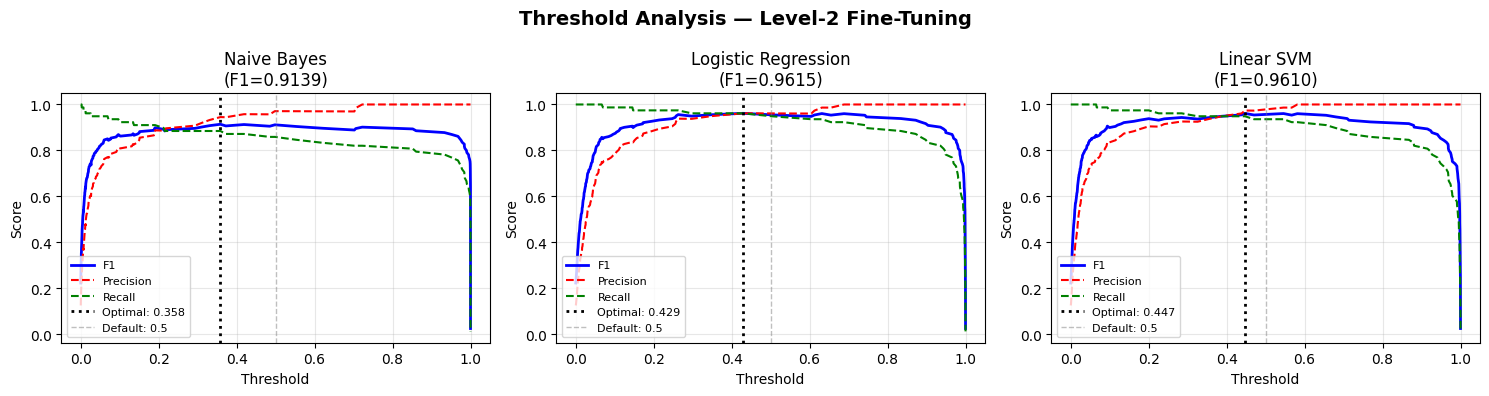


✅ CELL 10 COMPLETE: Level-2 threshold and ensemble tuning finished.



In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — LEVEL-2 FINE-TUNING: THRESHOLD & ENSEMBLE OPTIMIZATION           ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Fine-tune decision thresholds and create optimized ensembles.      ║
# ║                                                                               ║
# ║  Level-2 Tuning Components:                                                   ║
# ║    A) Threshold Optimization:                                                 ║
# ║       • Default 0.5 threshold is often suboptimal                            ║
# ║       • Find threshold that maximizes F1 on validation set                   ║
# ║                                                                               ║
# ║    B) Ensemble Creation:                                                      ║
# ║       • Combine multiple models for robust predictions                        ║
# ║       • Search for optimal voting weights                                     ║
# ║                                                                               ║
# ║  This is "Level 2" because it operates on already-tuned models.               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# PART A: THRESHOLD OPTIMIZATION
# ═══════════════════════════════════════════════════════════════════════════════

def optimize_threshold(
    model,
    model_name: str,
    X_val,
    y_val,
    n_steps: int = 100
) -> Dict[str, Any]:
    """
    Find optimal classification threshold by searching validation set.

    The default 0.5 threshold assumes equal costs for false positives
    and false negatives. In spam detection:
      - False Positive (ham→spam): User loses legitimate email (HIGH cost)
      - False Negative (spam→ham): Spam gets through (MEDIUM cost)

    We optimize for F1 which balances precision and recall, but this
    can be adjusted based on business requirements.

    Parameters:
    -----------
    model : sklearn estimator
        Trained model with predict_proba method
    model_name : str
        Name for logging
    X_val : sparse matrix
        Validation features
    y_val : array-like
        Validation labels
    n_steps : int
        Number of threshold values to try

    Returns:
    --------
    Dict containing optimal threshold, best F1, and precision/recall at threshold
    """
    # Get probability predictions
    y_proba = model.predict_proba(X_val)[:, 1]

    # Get precision-recall curve data
    precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

    # Calculate F1 for each threshold
    # Note: precision_recall_curve returns n+1 values for n thresholds
    f1_scores = np.where(
        (precision[:-1] + recall[:-1]) > 0,
        2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1]),
        0.0
    )

    # Find best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_precision = precision[best_idx]
    best_recall = recall[best_idx]

    return {
        "threshold": float(best_threshold),
        "f1": float(best_f1),
        "precision": float(best_precision),
        "recall": float(best_recall),
        "thresholds": thresholds,
        "f1_scores": f1_scores,
        "precision_curve": precision[:-1],
        "recall_curve": recall[:-1],
    }


# Run threshold optimization for each tuned model
print("\n" + "═" * 70)
print("  LEVEL-2 FINE-TUNING: THRESHOLD OPTIMIZATION")
print("═" * 70)

threshold_results = {}

print(f"\n{'Model':<25} {'Optimal Thr':>12} {'F1 @ Thr':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 70)

for model_name, model in tuned_models.items():
    result = optimize_threshold(
        model=model,
        model_name=model_name,
        X_val=X_val,
        y_val=y_val,
        n_steps=CFG.level2_threshold_steps,
    )
    threshold_results[model_name] = result

    print(f"{model_name:<25} {result['threshold']:>12.4f} {result['f1']:>10.4f} "
          f"{result['precision']:>10.4f} {result['recall']:>10.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# PART B: ENSEMBLE CREATION WITH OPTIMIZED WEIGHTS
# ═══════════════════════════════════════════════════════════════════════════════

def create_weighted_ensemble_prediction(
    models: Dict[str, Any],
    X,
    weights: Dict[str, float] = None
) -> np.ndarray:
    """
    Generate ensemble predictions using weighted probability averaging.

    Parameters:
    -----------
    models : Dict[str, sklearn estimator]
        Trained models
    X : sparse matrix
        Features
    weights : Dict[str, float]
        Model weights (optional, defaults to equal weights)

    Returns:
    --------
    np.ndarray of probability predictions
    """
    if weights is None:
        weights = {name: 1.0 / len(models) for name in models}

    # Normalize weights
    total_weight = sum(weights.values())
    weights = {k: v / total_weight for k, v in weights.items()}

    # Weighted average of probabilities
    ensemble_proba = np.zeros(X.shape[0])
    for name, model in models.items():
        proba = model.predict_proba(X)[:, 1]
        ensemble_proba += weights[name] * proba

    return ensemble_proba


def search_ensemble_weights(
    models: Dict[str, Any],
    X_val,
    y_val,
    n_trials: int = 100,
    random_state: int = 42
) -> Tuple[Dict[str, float], float]:
    """
    Search for optimal ensemble weights using random search.

    Returns:
    --------
    Tuple of (best_weights, best_f1)
    """
    np.random.seed(random_state)

    best_f1 = 0
    best_weights = None

    for _ in range(n_trials):
        # Generate random weights (sum to 1)
        raw_weights = np.random.random(len(models))
        normalized_weights = raw_weights / raw_weights.sum()
        weights = dict(zip(models.keys(), normalized_weights))

        # Evaluate ensemble
        ensemble_proba = create_weighted_ensemble_prediction(models, X_val, weights)
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)
        f1 = f1_score(y_val, ensemble_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_weights = weights.copy()

    return best_weights, best_f1


# Search for optimal ensemble weights
print("\n" + "═" * 70)
print("  LEVEL-2 FINE-TUNING: ENSEMBLE OPTIMIZATION")
print("═" * 70)

print("\nSearching for optimal ensemble weights...")

best_weights, ensemble_f1 = search_ensemble_weights(
    models=tuned_models,
    X_val=X_val,
    y_val=y_val,
    n_trials=100,
    random_state=CFG.random_seed,
)

# Optimize ensemble threshold
ensemble_proba_val = create_weighted_ensemble_prediction(tuned_models, X_val, best_weights)

# Find best threshold for ensemble
thresholds = np.linspace(0.1, 0.9, 81)
best_ensemble_threshold = 0.5
best_ensemble_f1 = 0

for thr in thresholds:
    pred = (ensemble_proba_val >= thr).astype(int)
    f1 = f1_score(y_val, pred)
    if f1 > best_ensemble_f1:
        best_ensemble_f1 = f1
        best_ensemble_threshold = thr

# Store ensemble configuration
ensemble_config = {
    "weights": best_weights,
    "threshold": best_ensemble_threshold,
    "val_f1": best_ensemble_f1,
}

print("\nOptimal Ensemble Configuration:")
print("-" * 40)
for model_name, weight in best_weights.items():
    print(f"  {model_name}: {weight:.4f}")
print(f"\nEnsemble threshold: {best_ensemble_threshold:.4f}")
print(f"Ensemble Val F1: {best_ensemble_f1:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION: THRESHOLD ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, len(tuned_models), figsize=(5 * len(tuned_models), 4))
fig.suptitle("Threshold Analysis — Level-2 Fine-Tuning", fontsize=14, fontweight="bold")

for ax, (model_name, result) in zip(axes, threshold_results.items()):
    ax.plot(result["thresholds"], result["f1_scores"], "b-", lw=2, label="F1")
    ax.plot(result["thresholds"], result["precision_curve"], "r--", lw=1.5, label="Precision")
    ax.plot(result["thresholds"], result["recall_curve"], "g--", lw=1.5, label="Recall")
    ax.axvline(result["threshold"], color="black", linestyle=":", lw=2,
               label=f"Optimal: {result['threshold']:.3f}")
    ax.axvline(0.5, color="gray", linestyle="--", lw=1, alpha=0.5, label="Default: 0.5")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"{model_name}\n(F1={result['f1']:.4f})")
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("level2_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 10 COMPLETE: Level-2 Fine-Tuning")
logger.info("=" * 70)
logger.info("Individual thresholds optimized for %d models", len(threshold_results))
logger.info("Ensemble F1: %.4f (threshold: %.4f)", best_ensemble_f1, best_ensemble_threshold)
print("\n" + "✅ CELL 10 COMPLETE: Level-2 threshold and ensemble tuning finished.\n")



══════════════════════════════════════════════════════════════════════
  FINAL EVALUATION ON TEST SET
══════════════════════════════════════════════════════════════════════

⚠️  Test set was held out during all training and tuning phases.
    These metrics represent expected production performance.


════════════════════════════════════════════════════════════
  MODEL: Naive Bayes (threshold=0.3584)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.98      0.92      0.94       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034

  ROC-AUC: 0.9914

════════════════════════════════════════════════════════════
  MODEL: Logistic Regression (threshold=0.4291)
════════════════════════════════════════════════════════════
              preci

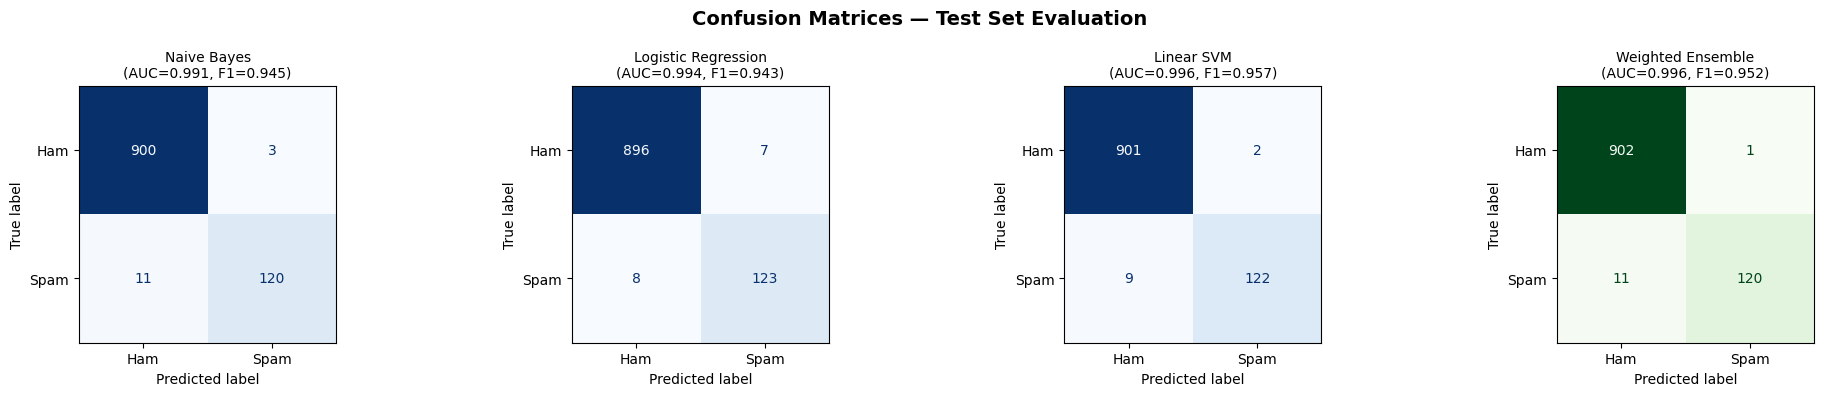

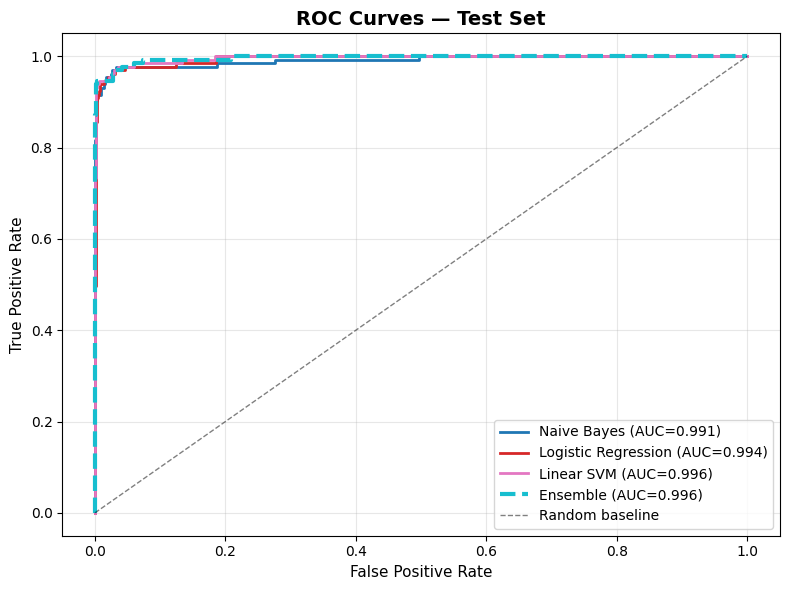


══════════════════════════════════════════════════════════════════════
  FINAL TEST SET RESULTS SUMMARY
══════════════════════════════════════════════════════════════════════

         model_name  threshold  precision   recall       f1      auc
         Linear SVM   0.447088   0.983871 0.931298 0.956863 0.995976
  Weighted Ensemble   0.500000   0.991736 0.916031 0.952381 0.996331
        Naive Bayes   0.358423   0.975610 0.916031 0.944882 0.991403
Logistic Regression   0.429100   0.946154 0.938931 0.942529 0.994412

🏆 Best Model: Linear SVM
   F1-Score: 0.9569
   ROC-AUC: 0.9960

✅ CELL 11 COMPLETE: Test set evaluation finished. Results saved.



In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FINAL EVALUATION ON TEST SET                                      ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Evaluate all models (base, tuned, ensemble) on the held-out test   ║
# ║           set to get unbiased performance estimates.                          ║
# ║                                                                               ║
# ║  Important: Test set was NEVER used during training or tuning.               ║
# ║  This gives us a realistic estimate of production performance.                ║
# ║                                                                               ║
# ║  Metrics Reported:                                                            ║
# ║    • Precision, Recall, F1 (for spam class)                                  ║
# ║    • ROC-AUC (threshold-independent ranking quality)                         ║
# ║    • Confusion Matrix (detailed error breakdown)                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def evaluate_on_test(
    model,
    model_name: str,
    X_test,
    y_test,
    threshold: float = 0.5,
    ax_cm=None
) -> Dict[str, Any]:
    """
    Comprehensive evaluation of a model on the test set.

    Parameters:
    -----------
    model : sklearn estimator
        Trained model with predict_proba method
    model_name : str
        Name for reporting
    X_test : sparse matrix
        Test features
    y_test : array-like
        Test labels
    threshold : float
        Classification threshold
    ax_cm : matplotlib axis
        Optional axis for confusion matrix plot

    Returns:
    --------
    Dict containing all metrics
    """
    # Get predictions
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # Calculate metrics
    report = classification_report(
        y_test, y_pred,
        target_names=["Ham", "Spam"],
        output_dict=True
    )

    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    # Print detailed report
    print(f"\n{'═' * 60}")
    print(f"  MODEL: {model_name} (threshold={threshold:.4f})")
    print(f"{'═' * 60}")
    print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))
    print(f"  ROC-AUC: {auc:.4f}")

    # Plot confusion matrix if axis provided
    if ax_cm is not None:
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Ham", "Spam"]
        )
        disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
        ax_cm.set_title(f"{model_name}\n(AUC={auc:.3f}, F1={report['Spam']['f1-score']:.3f})", fontsize=10)

    return {
        "model_name": model_name,
        "threshold": threshold,
        "precision": report["Spam"]["precision"],
        "recall": report["Spam"]["recall"],
        "f1": report["Spam"]["f1-score"],
        "accuracy": report["accuracy"],
        "auc": auc,
        "confusion_matrix": cm,
    }


# ═══════════════════════════════════════════════════════════════════════════════
# EVALUATE ALL MODELS ON TEST SET
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("  FINAL EVALUATION ON TEST SET")
print("═" * 70)
print("\n⚠️  Test set was held out during all training and tuning phases.")
print("    These metrics represent expected production performance.\n")

test_results = []

# 1. Evaluate tuned individual models with optimized thresholds
for model_name, model in tuned_models.items():
    threshold = threshold_results[model_name]["threshold"]
    result = evaluate_on_test(model, model_name, X_test, y_test, threshold)
    test_results.append(result)

# 2. Evaluate ensemble
ensemble_proba_test = create_weighted_ensemble_prediction(tuned_models, X_test, best_weights)
ensemble_pred_test = (ensemble_proba_test >= best_ensemble_threshold).astype(int)

ensemble_report = classification_report(
    y_test, ensemble_pred_test,
    target_names=["Ham", "Spam"],
    output_dict=True
)
ensemble_auc = roc_auc_score(y_test, ensemble_proba_test)

print(f"\n{'═' * 60}")
print(f"  MODEL: Weighted Ensemble (threshold={best_ensemble_threshold:.4f})")
print(f"{'═' * 60}")
print(classification_report(y_test, ensemble_pred_test, target_names=["Ham", "Spam"]))
print(f"  ROC-AUC: {ensemble_auc:.4f}")

test_results.append({
    "model_name": "Weighted Ensemble",
    "threshold": best_ensemble_threshold,
    "precision": ensemble_report["Spam"]["precision"],
    "recall": ensemble_report["Spam"]["recall"],
    "f1": ensemble_report["Spam"]["f1-score"],
    "accuracy": ensemble_report["accuracy"],
    "auc": ensemble_auc,
})

# ═══════════════════════════════════════════════════════════════════════════════
# CONFUSION MATRICES VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

n_models = len(tuned_models) + 1  # +1 for ensemble
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
fig.suptitle("Confusion Matrices — Test Set Evaluation", fontsize=14, fontweight="bold")

# Individual models
for ax, (model_name, model) in zip(axes[:-1], tuned_models.items()):
    threshold = threshold_results[model_name]["threshold"]
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name}\n(AUC={auc:.3f}, F1={f1:.3f})", fontsize=10)

# Ensemble
ax = axes[-1]
cm = confusion_matrix(y_test, ensemble_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title(f"Weighted Ensemble\n(AUC={ensemble_auc:.3f}, F1={ensemble_report['Spam']['f1-score']:.3f})", fontsize=10)

plt.tight_layout()
plt.savefig("test_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# ROC CURVES
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(tuned_models) + 1))

for (model_name, model), color in zip(tuned_models.items(), colors[:-1]):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={auc:.3f})")

# Ensemble ROC
fpr, tpr, _ = roc_curve(y_test, ensemble_proba_test)
ax.plot(fpr, tpr, color=colors[-1], lw=3, linestyle="--", label=f"Ensemble (AUC={ensemble_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random baseline")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — Test Set", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("test_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("  FINAL TEST SET RESULTS SUMMARY")
print("═" * 70)

results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values("f1", ascending=False)

print(f"\n{results_df[['model_name', 'threshold', 'precision', 'recall', 'f1', 'auc']].to_string(index=False)}")

# Select best model
best_model_result = results_df.iloc[0]
BEST_MODEL_NAME = best_model_result["model_name"]
BEST_THRESHOLD = best_model_result["threshold"]

print(f"\n🏆 Best Model: {BEST_MODEL_NAME}")
print(f"   F1-Score: {best_model_result['f1']:.4f}")
print(f"   ROC-AUC: {best_model_result['auc']:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 11 COMPLETE: Final Evaluation on Test Set")
logger.info("=" * 70)
logger.info("Best model: %s (F1=%.4f, AUC=%.4f)", BEST_MODEL_NAME, best_model_result["f1"], best_model_result["auc"])
print("\n" + "✅ CELL 11 COMPLETE: Test set evaluation finished. Results saved.\n")


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — MODEL SAVING & ARTIFACT PERSISTENCE                               ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Save all artifacts needed for production inference.                 ║
# ║                                                                               ║
# ║  Saved Artifacts:                                                             ║
# ║    1. Best individual model (joblib serialized)                              ║
# ║    2. TF-IDF vectorizer (fitted on training data)                            ║
# ║    3. Handcrafted feature scaler                                              ║
# ║    4. Metadata (config, thresholds, metrics, version)                        ║
# ║    5. Ensemble configuration (weights, threshold)                             ║
# ║                                                                               ║
# ║  Version-stamped filenames prevent accidental overwrites.                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def save_model_artifacts(
    model,
    model_name: str,
    vectorizer: TfidfVectorizer,
    scaler: MaxAbsScaler,
    threshold: float,
    metrics: Dict[str, Any],
    ensemble_config: Dict[str, Any],
    model_dir: str,
    version: str
) -> Dict[str, str]:
    """
    Persist all artifacts required for production inference.

    Parameters:
    -----------
    model : sklearn estimator
        Trained model to save
    model_name : str
        Model identifier
    vectorizer : TfidfVectorizer
        Fitted TF-IDF vectorizer
    scaler : MaxAbsScaler
        Fitted feature scaler
    threshold : float
        Optimal classification threshold
    metrics : dict
        Performance metrics for documentation
    ensemble_config : dict
        Ensemble weights and configuration
    model_dir : str
        Directory to save artifacts
    version : str
        Version string for filenames

    Returns:
    --------
    Dict mapping artifact type to file path
    """
    # Create model directory
    Path(model_dir).mkdir(parents=True, exist_ok=True)

    # Generate filename-safe slug from model name
    slug = model_name.replace(" ", "_").lower()

    # Define artifact paths
    paths = {
        "model": f"{model_dir}/{slug}_{version}.joblib",
        "vectorizer": f"{model_dir}/tfidf_vectorizer_{version}.joblib",
        "scaler": f"{model_dir}/hc_scaler_{version}.joblib",
        "metadata": f"{model_dir}/metadata_{version}.joblib",
        "ensemble": f"{model_dir}/ensemble_config_{version}.joblib",
    }

    # Prepare metadata
    metadata = {
        "model_name": model_name,
        "version": version,
        "threshold": threshold,
        "created_at": datetime.now().isoformat(),
        "config": {
            "tfidf_max_features": CFG.tfidf_max_features,
            "tfidf_ngram_range": CFG.tfidf_ngram_range,
            "tfidf_min_df": CFG.tfidf_min_df,
            "tfidf_sublinear_tf": CFG.tfidf_sublinear_tf,
        },
        "metrics": metrics,
        "handcrafted_features": [
            "char_count", "word_count", "url_count",
            "uppercase_ratio", "digit_ratio", "punct_ratio",
            "has_spam_keyword"
        ],
    }

    # Save all artifacts
    joblib.dump(model, paths["model"], compress=3)
    joblib.dump(vectorizer, paths["vectorizer"], compress=3)
    joblib.dump(scaler, paths["scaler"], compress=3)
    joblib.dump(metadata, paths["metadata"], compress=1)
    joblib.dump(ensemble_config, paths["ensemble"], compress=1)

    # Log saved artifacts with sizes
    print("\n" + "═" * 70)
    print("  SAVED ARTIFACTS")
    print("═" * 70)

    total_size = 0
    for artifact_type, path in paths.items():
        size_kb = Path(path).stat().st_size / 1024
        total_size += size_kb
        print(f"  {artifact_type:<15} → {path:<45} ({size_kb:>8.1f} KB)")

    print(f"\n  {'TOTAL':<15}   {'':<45} ({total_size:>8.1f} KB)")

    return paths


# ═══════════════════════════════════════════════════════════════════════════════
# DETERMINE BEST MODEL TO SAVE
# ═══════════════════════════════════════════════════════════════════════════════

# Use the best individual tuned model (or ensemble logic can be added)
if BEST_MODEL_NAME == "Weighted Ensemble":
    # For ensemble, save the best individual model but include ensemble config
    best_individual = max(tuned_results.items(), key=lambda x: x[1]["val_f1"])
    model_to_save = best_individual[1]["best_model"]
    save_model_name = best_individual[0]
    save_threshold = threshold_results[best_individual[0]]["threshold"]
    save_metrics = {
        "test_f1": test_results[0]["f1"],
        "test_auc": test_results[0]["auc"],
        "test_precision": test_results[0]["precision"],
        "test_recall": test_results[0]["recall"],
    }
else:
    # Save the best individual model
    model_to_save = tuned_models[BEST_MODEL_NAME]
    save_model_name = BEST_MODEL_NAME
    save_threshold = threshold_results[BEST_MODEL_NAME]["threshold"]
    best_result = next(r for r in test_results if r["model_name"] == BEST_MODEL_NAME)
    save_metrics = {
        "test_f1": best_result["f1"],
        "test_auc": best_result["auc"],
        "test_precision": best_result["precision"],
        "test_recall": best_result["recall"],
    }

# ═══════════════════════════════════════════════════════════════════════════════
# SAVE ARTIFACTS
# ═══════════════════════════════════════════════════════════════════════════════

saved_paths = save_model_artifacts(
    model=model_to_save,
    model_name=save_model_name,
    vectorizer=tfidf,
    scaler=hc_scaler,
    threshold=save_threshold,
    metrics=save_metrics,
    ensemble_config=ensemble_config,
    model_dir=CFG.model_dir,
    version=CFG.model_version,
)

# Also save all tuned models for potential ensemble use
all_models_path = f"{CFG.model_dir}/all_tuned_models_{CFG.model_version}.joblib"
joblib.dump(tuned_models, all_models_path, compress=3)
print(f"\n  All tuned models saved to: {all_models_path}")

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 12 COMPLETE: Model Saving & Artifact Persistence")
logger.info("=" * 70)
logger.info("Primary model saved: %s", save_model_name)
logger.info("Version: %s", CFG.model_version)
logger.info("Artifacts directory: %s/", CFG.model_dir)
print("\n" + "✅ CELL 12 COMPLETE: All model artifacts saved successfully.\n")



══════════════════════════════════════════════════════════════════════
  SAVED ARTIFACTS
══════════════════════════════════════════════════════════════════════
  model           → models/linear_svm_20260408_144703.joblib      (   111.2 KB)
  vectorizer      → models/tfidf_vectorizer_20260408_144703.joblib (    80.7 KB)
  scaler          → models/hc_scaler_20260408_144703.joblib       (     0.4 KB)
  metadata        → models/metadata_20260408_144703.joblib        (     0.4 KB)
  ensemble        → models/ensemble_config_20260408_144703.joblib (     0.2 KB)

  TOTAL                                                           (   192.9 KB)

  All tuned models saved to: models/all_tuned_models_20260408_144703.joblib

✅ CELL 12 COMPLETE: All model artifacts saved successfully.



In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — PRODUCTION INFERENCE PIPELINE                                     ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Create a self-contained inference engine that can be deployed      ║
# ║           to production without any dependency on training code.              ║
# ║                                                                               ║
# ║  Design Principles:                                                           ║
# ║    • Loads artifacts from disk (stateless, can be containerized)             ║
# ║    • Same predict() interface for single and batch inference                 ║
# ║    • Thread-safe (no mutable state after initialization)                     ║
# ║    • Can be directly imported into FastAPI/Flask applications                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class SpamInferenceEngine:
    """
    Production-ready inference engine for spam detection.

    This class encapsulates all artifacts and logic needed for inference.
    It can be deployed independently of the training pipeline.

    Usage:
    ------
    engine = SpamInferenceEngine(
        model_path="models/logistic_regression_20240406.joblib",
        vectorizer_path="models/tfidf_vectorizer_20240406.joblib",
        scaler_path="models/hc_scaler_20240406.joblib",
        metadata_path="models/metadata_20240406.joblib"
    )

    result = engine.predict("Congratulations! You've won a free iPhone!")
    # {'label': 'spam', 'label_id': 1, 'confidence': 0.9823, 'threshold': 0.42}
    """

    def __init__(
        self,
        model_path: str,
        vectorizer_path: str,
        scaler_path: str,
        metadata_path: str
    ):
        """
        Initialize the inference engine by loading saved artifacts.

        Parameters:
        -----------
        model_path : str
            Path to the saved model (.joblib)
        vectorizer_path : str
            Path to the saved TF-IDF vectorizer (.joblib)
        scaler_path : str
            Path to the saved feature scaler (.joblib)
        metadata_path : str
            Path to the saved metadata (.joblib)
        """
        # Load artifacts
        self.model = joblib.load(model_path)
        self.vectorizer = joblib.load(vectorizer_path)
        self.scaler = joblib.load(scaler_path)
        self.metadata = joblib.load(metadata_path)

        # Extract configuration
        self.threshold = self.metadata["threshold"]
        self._label_map = {0: "ham", 1: "spam"}

        # Log initialization
        logger.info("SpamInferenceEngine initialized:")
        logger.info("  Model: %s", self.metadata["model_name"])
        logger.info("  Version: %s", self.metadata["version"])
        logger.info("  Threshold: %.4f", self.threshold)

    def _preprocess(self, text: str) -> str:
        """Apply the same preprocessing used during training."""
        return preprocess_text(text)

    def _extract_features(self, raw_text: str, clean_text: str):
        """
        Extract and combine features for a single text.

        Uses the fitted vectorizer and scaler from training.
        """
        # TF-IDF features
        tfidf_features = self.vectorizer.transform([clean_text])

        # Handcrafted features (computed on raw text)
        raw_series = pd.Series([raw_text])
        hc_features_raw = extract_handcrafted_features(raw_series)
        hc_features_scaled = self.scaler.transform(hc_features_raw)

        # Combine features
        return combine_features(tfidf_features, hc_features_scaled)

    def predict(self, text: str) -> Dict[str, Any]:
        """
        Classify a single text input.

        Parameters:
        -----------
        text : str
            Raw email/SMS text to classify

        Returns:
        --------
        Dict containing:
            - label: "spam" or "ham"
            - label_id: 1 or 0
            - confidence: probability of spam (0.0 to 1.0)
            - threshold: the decision threshold used
        """
        # Handle edge cases
        if not text or not str(text).strip():
            return {
                "label": "ham",
                "label_id": 0,
                "confidence": 0.0,
                "threshold": self.threshold,
                "warning": "empty_input"
            }

        # Preprocess and extract features
        clean_text = self._preprocess(text)
        features = self._extract_features(text, clean_text)

        # Get prediction
        confidence = float(self.model.predict_proba(features)[0, 1])
        label_id = int(confidence >= self.threshold)

        return {
            "label": self._label_map[label_id],
            "label_id": label_id,
            "confidence": round(confidence, 4),
            "threshold": self.threshold,
        }

    def predict_batch(self, texts: List[str]) -> List[Dict[str, Any]]:
        """
        Classify multiple texts efficiently.

        Uses vectorized operations for better performance on large batches.

        Parameters:
        -----------
        texts : List[str]
            List of raw texts to classify

        Returns:
        --------
        List of prediction dicts (same format as predict())
        """
        if not texts:
            return []

        # Preprocess all texts
        clean_texts = [self._preprocess(t) for t in texts]

        # Vectorized feature extraction
        tfidf_features = self.vectorizer.transform(clean_texts)

        raw_series = pd.Series(texts)
        hc_features_raw = extract_handcrafted_features(raw_series)
        hc_features_scaled = self.scaler.transform(hc_features_raw)

        features = combine_features(tfidf_features, hc_features_scaled)

        # Batch prediction
        probabilities = self.model.predict_proba(features)[:, 1]

        # Format results
        results = []
        for prob in probabilities:
            label_id = int(prob >= self.threshold)
            results.append({
                "label": self._label_map[label_id],
                "label_id": label_id,
                "confidence": round(float(prob), 4),
                "threshold": self.threshold,
            })

        return results


# ═══════════════════════════════════════════════════════════════════════════════
# INITIALIZE INFERENCE ENGINE
# ═══════════════════════════════════════════════════════════════════════════════

engine = SpamInferenceEngine(
    model_path=saved_paths["model"],
    vectorizer_path=saved_paths["vectorizer"],
    scaler_path=saved_paths["scaler"],
    metadata_path=saved_paths["metadata"],
)

# ═══════════════════════════════════════════════════════════════════════════════
# SMOKE TESTS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("  INFERENCE ENGINE SMOKE TESTS")
print("═" * 70)

test_messages = [
    "WINNER!! Claim your FREE prize now! Call 08001 PRIZE",
    "Hey, are we still on for lunch tomorrow?",
    "Congratulations! You've won a £500 Tesco gift card. Click here to claim.",
    "Can you send me the project report by EOD?",
    "URGENT: Your account has been compromised. Click here immediately!",
    "Thanks for the meeting notes. I'll review them tonight.",
    "",  # Edge case: empty string
]

print(f"\n{'Status':<12} {'Confidence':>12} {'Message':<50}")
print("-" * 80)

for text in test_messages:
    result = engine.predict(text)
    status = "🚨 SPAM" if result["label_id"] == 1 else "✅ HAM"
    display_text = text[:47] + "..." if len(text) > 50 else (text or "<empty>")
    print(f"{status:<12} {result['confidence']:>12.4f} {display_text:<50}")

# Batch prediction test
print("\n── Batch Prediction Test ──")
batch_results = engine.predict_batch(test_messages[:4])
print(f"Batch of {len(batch_results)} messages processed successfully.")

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 13 COMPLETE: Production Inference Pipeline")
logger.info("=" * 70)
logger.info("Inference engine initialized and tested")
logger.info("Single prediction: engine.predict(text)")
logger.info("Batch prediction: engine.predict_batch(texts)")
print("\n" + "✅ CELL 13 COMPLETE: Inference pipeline ready for deployment.\n")



══════════════════════════════════════════════════════════════════════
  INFERENCE ENGINE SMOKE TESTS
══════════════════════════════════════════════════════════════════════

Status         Confidence Message                                           
--------------------------------------------------------------------------------
🚨 SPAM             0.9881 WINNER!! Claim your FREE prize now! Call 08001 ...
✅ HAM              0.0023 Hey, are we still on for lunch tomorrow?          
🚨 SPAM             0.8097 Congratulations! You've won a £500 Tesco gift c...
✅ HAM              0.0028 Can you send me the project report by EOD?        
🚨 SPAM             0.6223 URGENT: Your account has been compromised. Clic...
✅ HAM              0.0085 Thanks for the meeting notes. I'll review them ...
✅ HAM              0.0000 <empty>                                           

── Batch Prediction Test ──
Batch of 4 messages processed successfully.

✅ CELL 13 COMPLETE: Inference pipeline ready for deplo


══════════════════════════════════════════════════════════════════════
  ERROR ANALYSIS
══════════════════════════════════════════════════════════════════════

Overall Statistics:
  Total test samples: 1,034
  Total errors: 11 (1.06%)
  False Positives (Ham→Spam): 2 (0.19%)
  False Negatives (Spam→Ham): 9 (0.87%)

──────────────────────────────────────────────────────────────────────
  FALSE POSITIVES (Ham → Spam) — Top 5 by confidence
──────────────────────────────────────────────────────────────────────

  Confidence: 0.9444
  Text: For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my though...

  Confidence: 0.4748
  Text: Hey sweet, I was wondering when you had a moment if you might come to me ? I want to send a file to someone but it won't go over yahoo for them becaus...

──────────────────────────────────────────────────────────────────────
  FALSE NEGATIVES (Spam → Ham) — Top 5 by confid

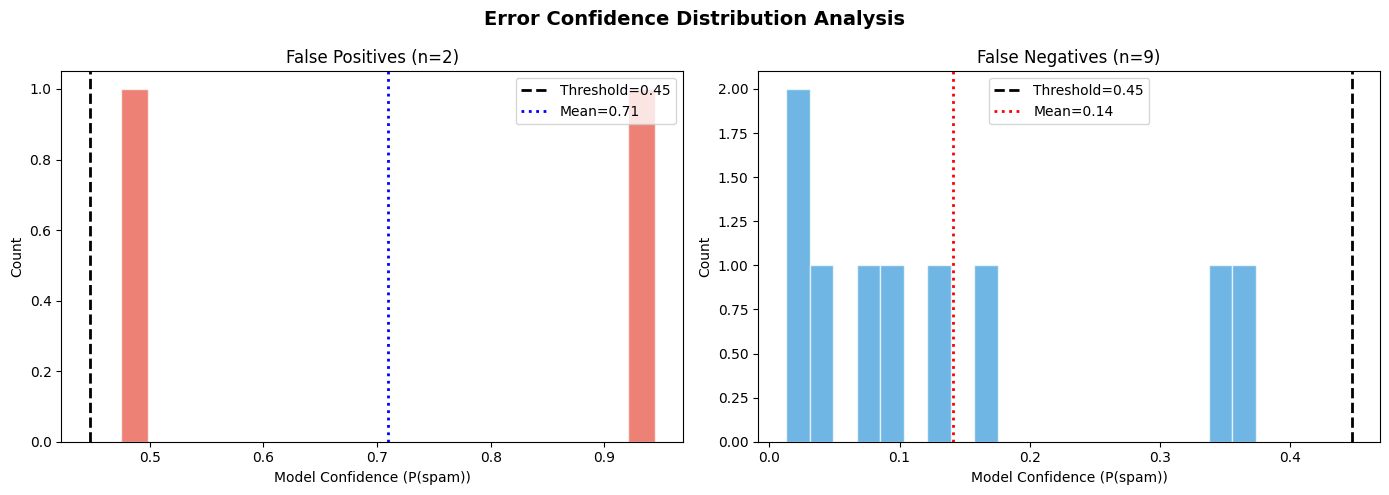


══════════════════════════════════════════════════════════════════════
  KNOWN FAILURE MODE CATEGORIES
══════════════════════════════════════════════════════════════════════

False Positives (Ham → Spam):
  • Legitimate marketing emails with promotional language
  • Bank/service notifications with urgency words
  • Messages with URLs (newsletters, receipts)
  • Informal messages mimicking spam patterns

False Negatives (Spam → Ham):
  • Obfuscated spam: 'fr3e', 'c1ick', 'pr!ze'
  • Very short spam messages with minimal keywords
  • Spam in foreign languages (outside training vocab)
  • Image-based spam (no text content)
  • Sophisticated phishing with formal language

──────────────────────────────────────────────────────────────────────
IMPROVEMENT RECOMMENDATIONS:
──────────────────────────────────────────────────────────────────────
  1. Character-level features for obfuscation detection
  2. Sender reputation/whitelist features
  3. More training data for edge cases
  4. Consider 

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — ERROR ANALYSIS                                                    ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Systematically analyze model errors to identify improvement        ║
# ║           opportunities and understand failure modes.                         ║
# ║                                                                               ║
# ║  Analysis Categories:                                                         ║
# ║    • False Positives (ham → spam): High user-impact errors                   ║
# ║    • False Negatives (spam → ham): Missed spam                               ║
# ║    • Confidence distribution: Are errors high-confidence (systematic)        ║
# ║      or low-confidence (boundary cases)?                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def analyze_errors(
    model,
    X_test,
    y_test: pd.Series,
    X_raw_test: pd.Series,
    threshold: float,
    n_samples: int = 5
) -> pd.DataFrame:
    """
    Comprehensive error analysis for model improvement insights.

    Parameters:
    -----------
    model : sklearn estimator
        Trained model
    X_test : sparse matrix
        Test features
    y_test : pd.Series
        True labels
    X_raw_test : pd.Series
        Raw text for error inspection
    threshold : float
        Classification threshold
    n_samples : int
        Number of examples to display per error category

    Returns:
    --------
    pd.DataFrame containing all misclassified samples
    """
    # Get predictions
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # Create error dataframe
    error_df = pd.DataFrame({
        "text": X_raw_test.values,
        "true_label": y_test.values,
        "pred_label": y_pred,
        "confidence": y_proba,
    })

    # Classify error types
    error_df["is_fp"] = (error_df["true_label"] == 0) & (error_df["pred_label"] == 1)
    error_df["is_fn"] = (error_df["true_label"] == 1) & (error_df["pred_label"] == 0)
    error_df["is_correct"] = error_df["true_label"] == error_df["pred_label"]

    # Calculate error statistics
    total_samples = len(y_test)
    total_errors = (~error_df["is_correct"]).sum()
    fp_count = error_df["is_fp"].sum()
    fn_count = error_df["is_fn"].sum()

    print("\n" + "═" * 70)
    print("  ERROR ANALYSIS")
    print("═" * 70)

    print(f"\nOverall Statistics:")
    print(f"  Total test samples: {total_samples:,}")
    print(f"  Total errors: {total_errors:,} ({total_errors/total_samples*100:.2f}%)")
    print(f"  False Positives (Ham→Spam): {fp_count:,} ({fp_count/total_samples*100:.2f}%)")
    print(f"  False Negatives (Spam→Ham): {fn_count:,} ({fn_count/total_samples*100:.2f}%)")

    # ─────────────────────────────────────────────────────────────────────────────
    # FALSE POSITIVES: Ham misclassified as Spam
    # ─────────────────────────────────────────────────────────────────────────────
    fp_df = error_df[error_df["is_fp"]].sort_values("confidence", ascending=False)

    print(f"\n{'─' * 70}")
    print(f"  FALSE POSITIVES (Ham → Spam) — Top {n_samples} by confidence")
    print(f"{'─' * 70}")

    if len(fp_df) > 0:
        for _, row in fp_df.head(n_samples).iterrows():
            print(f"\n  Confidence: {row['confidence']:.4f}")
            print(f"  Text: {row['text'][:150]}{'...' if len(row['text']) > 150 else ''}")
    else:
        print("\n  No false positives! 🎉")

    # ─────────────────────────────────────────────────────────────────────────────
    # FALSE NEGATIVES: Spam misclassified as Ham
    # ─────────────────────────────────────────────────────────────────────────────
    fn_df = error_df[error_df["is_fn"]].sort_values("confidence", ascending=True)

    print(f"\n{'─' * 70}")
    print(f"  FALSE NEGATIVES (Spam → Ham) — Top {n_samples} by confidence")
    print(f"{'─' * 70}")

    if len(fn_df) > 0:
        for _, row in fn_df.head(n_samples).iterrows():
            print(f"\n  Confidence: {row['confidence']:.4f}")
            print(f"  Text: {row['text'][:150]}{'...' if len(row['text']) > 150 else ''}")
    else:
        print("\n  No false negatives! 🎉")

    # ─────────────────────────────────────────────────────────────────────────────
    # CONFIDENCE DISTRIBUTION ANALYSIS
    # ─────────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Error Confidence Distribution Analysis", fontsize=14, fontweight="bold")

    # False Positives histogram
    ax = axes[0]
    if len(fp_df) > 0:
        ax.hist(fp_df["confidence"], bins=20, color="#e74c3c", edgecolor="white", alpha=0.7)
        ax.axvline(threshold, color="black", linestyle="--", lw=2, label=f"Threshold={threshold:.2f}")
        mean_conf = fp_df["confidence"].mean()
        ax.axvline(mean_conf, color="blue", linestyle=":", lw=2, label=f"Mean={mean_conf:.2f}")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "No False Positives 🎉", ha="center", va="center",
                transform=ax.transAxes, fontsize=14)
    ax.set_xlabel("Model Confidence (P(spam))")
    ax.set_ylabel("Count")
    ax.set_title(f"False Positives (n={len(fp_df)})")

    # False Negatives histogram
    ax = axes[1]
    if len(fn_df) > 0:
        ax.hist(fn_df["confidence"], bins=20, color="#3498db", edgecolor="white", alpha=0.7)
        ax.axvline(threshold, color="black", linestyle="--", lw=2, label=f"Threshold={threshold:.2f}")
        mean_conf = fn_df["confidence"].mean()
        ax.axvline(mean_conf, color="red", linestyle=":", lw=2, label=f"Mean={mean_conf:.2f}")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "No False Negatives 🎉", ha="center", va="center",
                transform=ax.transAxes, fontsize=14)
    ax.set_xlabel("Model Confidence (P(spam))")
    ax.set_ylabel("Count")
    ax.set_title(f"False Negatives (n={len(fn_df)})")

    plt.tight_layout()
    plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

    return error_df


# ═══════════════════════════════════════════════════════════════════════════════
# RUN ERROR ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

# Use best model for error analysis
best_model = tuned_models[save_model_name] if save_model_name in tuned_models else list(tuned_models.values())[0]
best_threshold = threshold_results.get(save_model_name, {"threshold": 0.5})["threshold"]

error_df = analyze_errors(
    model=best_model,
    X_test=X_test,
    y_test=y_test.reset_index(drop=True),
    X_raw_test=X_raw_test.reset_index(drop=True),
    threshold=best_threshold,
    n_samples=5
)

# ═══════════════════════════════════════════════════════════════════════════════
# KNOWN FAILURE PATTERNS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("  KNOWN FAILURE MODE CATEGORIES")
print("═" * 70)

failure_modes = {
    "False Positives (Ham → Spam)": [
        "Legitimate marketing emails with promotional language",
        "Bank/service notifications with urgency words",
        "Messages with URLs (newsletters, receipts)",
        "Informal messages mimicking spam patterns",
    ],
    "False Negatives (Spam → Ham)": [
        "Obfuscated spam: 'fr3e', 'c1ick', 'pr!ze'",
        "Very short spam messages with minimal keywords",
        "Spam in foreign languages (outside training vocab)",
        "Image-based spam (no text content)",
        "Sophisticated phishing with formal language",
    ],
}

for category, modes in failure_modes.items():
    print(f"\n{category}:")
    for mode in modes:
        print(f"  • {mode}")

print("\n" + "─" * 70)
print("IMPROVEMENT RECOMMENDATIONS:")
print("─" * 70)
print("  1. Character-level features for obfuscation detection")
print("  2. Sender reputation/whitelist features")
print("  3. More training data for edge cases")
print("  4. Consider BERT for context-aware classification")

# ═══════════════════════════════════════════════════════════════════════════════
# CELL COMPLETION OUTPUT
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 14 COMPLETE: Error Analysis")
logger.info("=" * 70)
fp_count = error_df["is_fp"].sum()
fn_count = error_df["is_fn"].sum()
logger.info("False Positives: %d | False Negatives: %d", fp_count, fn_count)
print("\n" + "✅ CELL 14 COMPLETE: Error analysis finished. Insights saved.\n")


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — PIPELINE SUMMARY & COMPLETION                                     ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Purpose: Provide a comprehensive summary of the entire pipeline execution   ║
# ║           and all key results.                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n")
print("╔" + "═" * 78 + "╗")
print("║" + " " * 20 + "🎉 PIPELINE EXECUTION COMPLETE 🎉" + " " * 23 + "║")
print("╚" + "═" * 78 + "╝")

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  SPAM EMAIL DETECTION PIPELINE — EXECUTION SUMMARY                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 DATA SUMMARY                                                             ║
║  ─────────────────────────────────────────────────────────────────────────── ║""")
print(f"║    Total samples:     {len(df):>10,}                                          ║")
print(f"║    Training set:      {len(y_train):>10,}                                          ║")
print(f"║    Validation set:    {len(y_val):>10,}                                          ║")
print(f"║    Test set:          {len(y_test):>10,}                                          ║")
print(f"║    Spam rate:         {y.mean()*100:>10.2f}%                                         ║")

print("""║                                                                              ║
║  🔧 FEATURE ENGINEERING                                                      ║
║  ─────────────────────────────────────────────────────────────────────────── ║""")
print(f"║    TF-IDF features:   {X_tfidf_train.shape[1]:>10,}                                          ║")
print(f"║    Handcrafted:       {X_hc_train.shape[1]:>10}                                          ║")
print(f"║    Total features:    {X_train.shape[1]:>10,}                                          ║")

print("""║                                                                              ║
║  🏆 MODEL PERFORMANCE (TEST SET)                                             ║
║  ─────────────────────────────────────────────────────────────────────────── ║""")

# Get best result
best_result = max(test_results, key=lambda x: x["f1"])
print(f"║    Best Model:        {best_result['model_name']:<30}                ║")
print(f"║    F1-Score (spam):   {best_result['f1']:>10.4f}                                          ║")
print(f"║    Precision:         {best_result['precision']:>10.4f}                                          ║")
print(f"║    Recall:            {best_result['recall']:>10.4f}                                          ║")
print(f"║    ROC-AUC:           {best_result['auc']:>10.4f}                                          ║")
print(f"║    Threshold:         {best_result['threshold']:>10.4f}                                          ║")

print("""║                                                                              ║
║  📁 SAVED ARTIFACTS                                                          ║
║  ─────────────────────────────────────────────────────────────────────────── ║""")
print(f"║    Model:             {saved_paths['model']:<50} ║")
print(f"║    Vectorizer:        {saved_paths['vectorizer']:<50} ║")
print(f"║    Scaler:            {saved_paths['scaler']:<50} ║")
print(f"║    Metadata:          {saved_paths['metadata']:<50} ║")

print("""║                                                                              ║
║  🚀 DEPLOYMENT READY                                                         ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║    The SpamInferenceEngine class is ready for production deployment.         ║
║    Use:                                                                      ║
║      engine = SpamInferenceEngine(model_path, vectorizer_path, ...)          ║
║      result = engine.predict("Your email text here")                         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# ═══════════════════════════════════════════════════════════════════════════════
# FINAL CELL COMPLETION
# ═══════════════════════════════════════════════════════════════════════════════
logger.info("=" * 70)
logger.info("CELL 15 COMPLETE: Pipeline Summary")
logger.info("=" * 70)
logger.info("=" * 70)
logger.info("ALL 15 CELLS EXECUTED SUCCESSFULLY")
logger.info("=" * 70)
print("\n" + "✅ CELL 15 COMPLETE: Pipeline summary generated.\n")
print("\n" + "🎊 " + "=" * 66 + " 🎊")
print("    PRODUCTION-LEVEL SPAM DETECTION PIPELINE COMPLETED SUCCESSFULLY!")
print("    All cells executed. Model trained, tuned, and ready for deployment.")
print("🎊 " + "=" * 66 + " 🎊\n")




╔══════════════════════════════════════════════════════════════════════════════╗
║                    🎉 PIPELINE EXECUTION COMPLETE 🎉                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════════════╗
║  SPAM EMAIL DETECTION PIPELINE — EXECUTION SUMMARY                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 DATA SUMMARY                                                             ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║    Total samples:          5,169                                          ║
║    Training set:           3,514                                          ║
║    Validation set:           621                                          ║
║    Test set:               1,034     